In [1]:
# ==============================================================================================
# VISA NOTEBOOK 2 — STREAMLINED PARALLEL ARCHITECTURE (Standard CLIP ‖ AnomalyCLIP)
# ==============================================================================================
# This file is laid out as literal Kaggle/Jupyter CELLS. Each "# %%" + banner marks one cell.
# Paste each block into its own notebook cell, in order. Cells 0–5 are carried over unchanged
# (or lightly hardened) from the original NB2; Cells 6–16 are the new architecture described in
# Part 1 of the accompanying change-log (temperature calibration, entropy gating, orthogonal
# subspace projection, Mahalanobis OOD gate, entropy arbitration, and the two mandated
# visualization cells).
# ==============================================================================================

In [2]:
# ============================================================================
# Cell 0: Project Structure, I/O Logging, Deterministic Execution & GPU Safety Env
# ============================================================================
import os
import torch
import random
import numpy as np
from pathlib import Path

# GPU SAFETY: reduces CUDA allocator fragmentation when two large backbones (ViT-B-32 +
# ViT-L/14) share VRAM concurrently for the parallel dual-stream design.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def build_project_structure(base_dir="/kaggle/working/visa_nb2"):
    dirs = ['configs', 'artifacts', 'results', 'metrics', 'ablations', 'figures', 'logs']
    for d in dirs:
        (Path(base_dir) / d).mkdir(parents=True, exist_ok=True)

seed_everything(42)
build_project_structure()

In [3]:
# ============================================================================
# Cell 1: Global Dataset, NB1 Toggles & Streamlined Parallel Architecture Config
# ============================================================================
print("⚙️ Initializing Master Pipeline Configuration...")

# 1. CLASS CONTROL
ACTIVE_CLASSES = [
    'candle', 'capsules', 'cashew', 'chewinggum', 'fryum',
    'macaroni1', 'macaroni2', 'pcb1', 'pcb2', 'pcb3', 'pcb4', 'pipe_fryum'
]
categories_to_run = ACTIVE_CLASSES

# 2. NB1 ABLATION CONTROL: Toggle which NB1 crop-generation outputs to load from
RUN_NB1_BASELINE         = True
RUN_NB1_PADDING_25       = False
RUN_NB1_PADDING_75       = False
RUN_NB1_SCALE_DYNAMIC    = False
RUN_NB1_GEOMETRY_RAW     = False

def get_active_nb1_configs():
    configs = []
    if RUN_NB1_BASELINE:         configs.append("Baseline_NB1")
    if RUN_NB1_PADDING_25:       configs.append("Padding_Ratio_25")
    if RUN_NB1_PADDING_75:       configs.append("Padding_Ratio_75")
    if RUN_NB1_SCALE_DYNAMIC:    configs.append("Scale_Dynamic_Ratio")
    if RUN_NB1_GEOMETRY_RAW:     configs.append("Geometry_Raw_Rect")
    return configs

ACTIVE_NB1_CONFIGS = get_active_nb1_configs()
nb1_configs_to_run = ACTIVE_NB1_CONFIGS

# 3. NEW — STREAMLINED PARALLEL ARCHITECTURE CONFIG
# Centralizes every constant used by the calibration / entropy / projection / OOD / arbitration
# modules below so nothing is a "magic number" buried in a function body.
ENTROPY_PERCENTILE   = 99     # percentile of validation entropy used as the uncertainty gate (Step 3)
MAHALANOBIS_PERCENTILE = 99   # percentile of validation Mahalanobis distance used as the OOD limit (Step 5.5)
TTA_ROTATION_DEG     = 5      # +/- rotation angle used by the Deep Enhancement Module (Step 4)
FUSION_ALPHA         = 0.7    # Tight-crop weight in Static Feature Fusion (Step 5)
FUSION_BETA          = 0.3    # Context-crop weight in Static Feature Fusion (Step 5)
GPU_MIN_FREE_GB      = 2.0    # VRAM headroom (GB) required before both backbones are trusted in FP32

print(f"✅ Active Classes: {len(categories_to_run)} selected.")
print(f"✅ Active NB1 Ablations: {nb1_configs_to_run}")
print(f"✅ Parallel Architecture Config: entropy_pct={ENTROPY_PERCENTILE}, mahalanobis_pct={MAHALANOBIS_PERCENTILE}, "
      f"alpha/beta={FUSION_ALPHA}/{FUSION_BETA}")

⚙️ Initializing Master Pipeline Configuration...
✅ Active Classes: 12 selected.
✅ Active NB1 Ablations: ['Baseline_NB1']
✅ Parallel Architecture Config: entropy_pct=99, mahalanobis_pct=99, alpha/beta=0.7/0.3


In [4]:
# ============================================================================
# Cell 1.1: Global Paths & Auxiliary Validation (UNCHANGED)
# ============================================================================
import os
from pathlib import Path

DATASET_ROOT = Path("/kaggle/input/datasets/ess1004/visa-anomaly-detection")
ROOT_INPUT_PATH = Path("/kaggle/input/notebooks/abhishek0300121/visa-nb1-research/results/ablations")

def get_current_base_path(nb1_config):
    return ROOT_INPUT_PATH / nb1_config

def verify_input_paths(dataset_root, root_input_path, nb1_config, active_categories):
    print(f"🔍 Verifying Input Paths and Auxiliary Artifacts for config: {nb1_config}...")
    if not dataset_root.exists():
        raise FileNotFoundError(f"❌ VisA dataset not found.")

    base_input_path = root_input_path / nb1_config
    if not base_input_path.exists():
        raise FileNotFoundError(f"❌ NB1 Configuration directory not found at {base_input_path}.")
    print(f"✅ NB1 Ablation Crops located at: {base_input_path}")

    valid_categories = []
    req_dirs = ["crops/tight", "crops/context", "heatmaps", "binary_masks"]
    for category in active_categories:
        category_path = base_input_path / category.lower()
        if category_path.exists() and category_path.is_dir():
            has_all_req_dirs = all((category_path / rd).exists() for rd in req_dirs)
            if has_all_req_dirs:
                valid_categories.append(category)
            else:
                print(f"⚠️ Category '{category}' missing required subdirectories. Skipping.")
        else:
            print(f"⚠️ Category '{category}' not found in {base_input_path}. Skipping.")

    print(f"📦 Filtering execution to {len(valid_categories)} valid categories.")
    return valid_categories

if 'ACTIVE_NB1_CONFIGS' in globals() and 'categories_to_run' in globals() and len(ACTIVE_NB1_CONFIGS) > 0:
    categories = verify_input_paths(DATASET_ROOT, ROOT_INPUT_PATH, ACTIVE_NB1_CONFIGS[0], categories_to_run)
else:
    print("⚠️ ACTIVE_NB1_CONFIGS or categories_to_run not defined. Run Cell 1 first.")
    categories = []

🔍 Verifying Input Paths and Auxiliary Artifacts for config: Baseline_NB1...
✅ NB1 Ablation Crops located at: /kaggle/input/notebooks/abhishek0300121/visa-nb1-research/results/ablations/Baseline_NB1
📦 Filtering execution to 12 valid categories.


In [5]:
# ============================================================================
# Cell 2: Ground Truth Pre-loading & Mapping (UNCHANGED)
# ============================================================================
import pandas as pd
from pathlib import Path

def build_ground_truth_map(dataset_root, root_input_path, nb1_config, active_categories):
    print(f"🗺️ Building Ground Truth Mapping Dictionary for {nb1_config}...")
    ground_truth_map = {}

    for category in active_categories:
        cat_dir = None
        for d in dataset_root.iterdir():
            if d.name.lower() == category.lower():
                cat_dir = d
                break
        if cat_dir is None:
            print(f"⚠️ Dataset directory for category '{category}' not found. Skipping annotations.")
            continue

        csv_path = cat_dir / "image_anno.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            anomaly_df = df[df['image'].str.contains('Anomaly', case=False, na=False)]
            for _, row in anomaly_df.iterrows():
                filename = Path(row['image']).name
                label = row['label']
                comp_key = f"{category.lower()}_{filename}"
                ground_truth_map[comp_key] = label
        else:
            print(f"⚠️ Annotation CSV not found for '{category}'.")

    print(f"✅ Successfully pre-loaded {len(ground_truth_map)} ground truth annotations into RAM.\n")
    return ground_truth_map

if 'ACTIVE_NB1_CONFIGS' in globals() and len(ACTIVE_NB1_CONFIGS) > 0 and len(categories) > 0:
    ground_truth_map = build_ground_truth_map(DATASET_ROOT, ROOT_INPUT_PATH, ACTIVE_NB1_CONFIGS[0], categories)
else:
    print("⚠️ Cannot build Ground Truth map: Missing active configs or verified categories.")

🗺️ Building Ground Truth Mapping Dictionary for Baseline_NB1...
✅ Successfully pre-loaded 1200 ground truth annotations into RAM.



In [6]:
# ============================================================================
# Cell 3: Global Prompt Engineering & Defect Mapping (UNCHANGED — carried in full, no data lost)
# ============================================================================
DEFECT_MAP = {
    "CANDLE": {
        "damaged corner of packaging": ["damaged corner of cardboard packaging", "torn cardboard packaging edge", "crushed cardboard packaging edge", "folded cardboard packaging", "bent cardboard box corner"],
        "different colour spot": ["different colour wax spot", "red colour wax spot", "discolored red wax patch", "red color stain on wax", "reddish orange wax spot", "strange dye patch on wax"],
        "chunk of wax missing": ["hollowed wax surface", "chipped wax chunk", "missing wax chunk", "wax surface crater", "wide hole with deformed wax surface", "hole with deformed wax surface", "wax surface chipped off", "dented wax surface"],
        "foreign particals on candle": ["foreign particles in wax", "debris embedded in wax", "embedded dirt in wax", "brown splotches on wax surface", "dark spread out splotches on wax", "external matter in wax"],
        "wax melded out of the candle": ["deformed wax shape", "misshapen wax drippings", "wax melted out", "excess wax settled outside", "wax causing candle to misshapen"],
        "weird candle wick": ["frayed cotton wick", "broken candle wick", "split string in cotton wick", "off center cotton wick"],
        "extra wax in candle": ["excess wax buildup", "wax overflow", "wax lump", "overpoured wax", "raised wax blob"]
    },
    "CAPSULES": {
        "bubble": ["internal bubble formation", "air pocket", "bubble formed within capsule", "small air pocket", "trapped air pocket"],
        "discolor": ["dark discoloration", "dark colour spot", "discolored black patch", "brown color stain"],
        "scratch": ["scratch", "surface scratch", "scuff mark", "shallow scrape", "marred exterior"],
        "leak": ["leak", "ruptured capsule", "leaking dark liquid", "oozing contents", "punctured shell"],
        "misshape": ["misshapen", "deformed", "crushed capsule", "expanded air pocket", "discolored with a bubble", "irregular shape", "surface bulge"]
    },
    "CASHEW": {
        "small holes": ["tiny holes", "small punctures", "one small hole", "tiny hole with surface deformity", "multiple holes"],
        "small scratches": ["small scratches", "surface scratch", "multiple scratches", "elongated surface scratch", "linear scratch", "shallow scrape"],
        "corner or edge breakage": ["chipped edge", "broken corner", "tiny edge broken", "tiny scratch on the edge", "uneven cashew shape", "snapped tip"],
        "burnt": ["burnt spot", "slightly charred spot", "reddish brown spot", "brown burn spot", "dark burn patch", "uneven roasting"],
        "same colour spot": ["same colour spot", "raised bump", "surface protrusion", "lumpy area"],
        "different colour spot": ["different colour spot", "dark stain", "discoloration", "dark colour patches", "discolouration"],
        "middle breakage": ["surface chipped off", "light stain with a hole", "dented surface", "wide hole with deformed surface", "hole with deformed surface"],
        "stuck together": ["stuck together", "fused cashews", "clustered nuts", "two deformed cashews", "deformed cashew", "double cashew"]
    },
    "CHEWINGGUM": {
        "similar colour spot": ["raised sugary blemish", "white gum deformity", "white bumpy sugary surface", "protruding gum lump"],
        "chunk of gum missing": ["chunk of gum missing", "sugary gum crater", "hollowed main gum surface", "dented gum center", "wide hole with deformed sugary surface", "gum surface crater"],
        "small cracks": ["small cracks in sugary coating", "tiny gum surface cracks", "sugary surface unevenness", "small cracks over the gum edge"],
        "corner missing": ["broken gum corner", "missing sugary edge chunk", "chipped outer gum border", "chipped gum corner chunk", "deformed hole on the gum side", "deformed sugary edge", "gum surface chipped off"],
        "scratches": ["sugary surface scratch", "elongated surface scratch on gum", "linear gum scratch", "uneven sugary edge scratch", "multiple linear gum scratches", "shallow scrape on gum"]
    },
    "FRYUM": {
        "fryum stuck together": ["stuck together", "fused fryums", "clustered pieces", "two deformed fryums", "deformed fryum", "double fryum", "stacked fryums", "double broken fryum"],
        "middle breakage": ["surface chipped off", "broken ridges", "missing chunk", "cracked surface with missing chunk"],
        "different colour spot": ["dark colour spot", "red colour spot", "red color stain", "discolored brown splotches", "red patches", "brown color stain", "discoloured spot", "brown colour splotches"],
        "similar colour spot": ["raised bump", "light textured spot", "deformed ridge", "surface lump"],
        "burnt": ["burnt spot", "slightly charred spot", "brown patch deformity", "brown textured patch", "deformed burn spots"],
        "corner or edge breakage": ["tiny edge broken", "chipped fryum corner", "tiny breakage on the edge", "uneven circle edge", "fractured rim"],
        "small scratches": ["small scratches", "surface scratch", "shallow scrape", "uneven surface grooves"]
    },
    "MACARONI1": {
        "similar colour spot": ["similar colour spot", "raised bump", "textured spot", "surface lump", "uneven bumpy surface", "protruding lump"],
        "chip around edge and corner": ["broken edge", "chipped corner", "fractured pasta rim", "snapped border", "broken rim"],
        "small scratches": ["small scratches", "surface scratch", "elongated surface scratch", "linear scratch", "uneven edge scratch"],
        "different colour spot": ["dark stain", "discoloration", "abnormal red patch", "brown patch mark", "red discoloration", "brown spots", "discolored brown line", "discoloured linear spot"],
        "small cracks": ["small cracks", "tiny surface cracks", "surface unevenness", "small cracks over the edge", "elongated cracked surface"],
        "middle breakage": ["hollowed main surface", "small holes", "dented center", "tiny hole with deformed surface", "central missing chunk", "surface crater"]
    },
    "MACARONI2": {
        "color spot similar to the object": ["raised bump", "surface lump", "pasta coloured bump", "white deformity", "yellow surface", "light discoloration", "protruding lump"],
        "small chip around edge": ["small chip around edge", "broken edge", "chipped corner", "fractured pasta rim", "broken rim"],
        "small scratches": ["white small scratches", "surface scratch", "shallow scrape", "linear scratch", "deformed white scratches"],
        "different color spot": ["different color spot", "discolored patch", "unusual pigmentation", "black patchy texture"],
        "breakage down the middle": ["hollowed main surface", "small holes", "dented center", "tiny hole with deformed surface", "central missing chunk", "surface crater"],
        "small cracks": ["small cracks", "tiny surface cracks", "surface unevenness", "small cracks over the edge", "elongated cracked surface", "linear surface unevenness"]
    },
    "PIPE_FRYUM": {
        "similar colour spot": ["raised bump", "surface lump", "uneven bumpy surface", "pasta coloured bump", "white deformity", "light discoloration", "light stain patch"],
        "small scratches": ["small scratches", "surface scratch", "shallow scrape", "linear scratch", "scuffed snack surface", "elongated surface scrape"],
        "corner and edge breakage": ["chipped edge", "broken corner", "fractured rim", "snapped border", "cracked rim edge", "broken tube end"],
        "burnt": ["burnt patch", "charred spot", "brown burnt patch", "reddish brown spot", "brown burn spot", "dark burn patch", "uneven roasting", "overcooked patch"],
        "stuck together": ["stuck together", "fused fryums", "two deformed fryums", "double fryum", "stacked fryums", "double broken fryum"],
        "different colour spot": ["dark stain", "abnormal pigment patch", "unusual tint mark", "unusual pigmentation", "black patchy texture"],
        "middle breakage": ["punctured hole", "hollowed main surface", "small holes", "dented center", "tiny hole with deformed surface", "surface crater"],
        "small cracks": ["small cracks", "tiny surface cracks", "surface unevenness", "small cracks over the edge", "elongated cracked surface", "linear surface unevenness"]
    },
    "PCB1": {
        "melt": ["melted solder", "brown heat damage", "white melted solder", "silver melted solder", "misplaced solder melts", "thermal deformation"],
        "missing": ["missing component", "absent part", "missing circular pads", "missing mesh", "missing pins", "vacant slot"],
        "bent": ["bent pin", "two bent pins", "overlapping bent pins", "three bent pins", "pins bent over each other"],
        "scratch": ["scratch mark", "surface scratched", "elongated scratches", "linear scratches on surface", "scraped board"]
    },
    "PCB2": {
        "melt": ["melted solder", "brown heat damage", "white melted solder", "silver melted solder", "misplaced solder melts", "thermal deformation"],
        "missing": ["missing component", "component out of place", "missing chips", "missing pins", "vacant chip slot"],
        "bent": ["bent pin", "two bent pins", "overlapping bent pins", "three bent pins", "pins bent over each other"],
        "scratch": ["scratch mark", "surface scratched", "elongated scratches", "linear scratches on surface", "scraped board"]
    },
    "PCB3": {
        "melt": ["melted solder", "brown heat damage", "white melted solder", "silver melted solder", "misplaced solder melts", "thermal deformation"],
        "missing": ["missing component", "component out of place", "missing chips", "missing pins", "vacant chip slot", "missing LED bulb", "missing black blob", "missing pins"],
        "bent": ["bent pin", "two bent pins", "overlapping bent pins", "three bent pins", "pins bent over each other"],
        "scratch": ["scratch mark", "surface scratched", "elongated scratches", "linear scratches on surface", "scraped board"]
    },
    "PCB4": {
        "missing": ["missing component", "component out of place", "missing chips", "missing pins", "vacant chip slot", "missing pins"],
        "extra": ["extra component", "unwanted part", "extra black component", "out of place dark black part"],
        "dirt": ["dirt patches", "debris sprinkled", "dark colour spot", "discolored patch", "discolored brown patches", "brown color stain", "brown colour splotches", "dust particles"],
        "wrong place": ["wrong place", "misaligned component", "incorrect placement", "shifted part", "positioning error"],
        "damage": ["broken part", "physical damage", "cracked component", "structural failure"],
        "burnt": ["burnt spot", "brown charred spot", "brown burnt patch", "reddish brown spot", "brown burn spot", "dark burn patch", "thermal burn mark"],
        "scratch": ["scratch mark", "surface scratched", "elongated scratches", "linear scratches on surface", "scraped board"]
    }
}

TEMPLATES = [
    "a bad photo of a {} with {}.", "a low resolution photo of the {} with {}.", "a bad photo of the {} with {}.",
    "a cropped photo of the {} with {}.", "a bright photo of a {} with {}.", "a dark photo of the {} with {}.",
    "a photo of my {} with {}.", "a photo of the cool {} with {}.", "a close-up photo of a {} with {}.",
    "a black and white photo of the {} with {}.", "a bright photo of the {} with {}.", "a cropped photo of a {} with {}.",
    "a jpeg corrupted photo of a {} with {}.", "a blurry photo of the {} with {}.", "a photo of the {} with {}.",
    "a good photo of the {} with {}.", "a photo of one {} with {}.", "a close-up photo of the {} with {}.",
    "a photo of a {} with {}.", "a low resolution photo of a {} with {}.", "a photo of a large {} with {}.",
    "a blurry photo of a {} with {}.", "a jpeg corrupted photo of the {} with {}.", "a good photo of a {} with {}.",
    "a photo of the small {} with {}.", "a photo of the large {} with {}.", "a black and white photo of a {} with {}.",
    "a dark photo of a {} with {}.", "a photo of a cool {} with {}.", "a photo of a small {} with {}.",
    "there is a {} with {} in the scene.", "there is the {} with {} in the scene.", "this is a {} with {} in the scene.",
    "this is the {} with {} in the scene.", "this is one {} with {} in the scene."
]

def generate_anomaly_prompts(defect_map, templates, category):
    cat_key = category.upper()
    if cat_key not in defect_map:
        return [f"a photo of a defective {category.lower()}."], {"defective": "defective"}
    synonym_dict = defect_map[cat_key]
    ensembled_text_array = []
    flat_synonyms_to_root = {}
    for root_label, synonyms in synonym_dict.items():
        for synonym in synonyms:
            flat_synonyms_to_root[synonym] = root_label
            for template in templates:
                sentence = template.format(category.lower(), synonym)
                ensembled_text_array.append(sentence)
    return ensembled_text_array, flat_synonyms_to_root

In [7]:
# ============================================================================
# Cell 4: Standard CLIP Dynamic Material Anchoring (UNCHANGED)
# ============================================================================
MATERIAL_ANCHORS = {
    "CANDLE": "on a wax candle", "CAPSULES": "on a transparent plastic capsule", "CASHEW": "on an organic cashew nut",
    "CHEWINGGUM": "on sugary chewing gum", "FRYUM": "on a fried dough snack", "MACARONI1": "on wheat pasta",
    "MACARONI2": "on curved wheat pasta", "PIPE_FRYUM": "on a tubular fried snack",
    "PCB1": "on a printed circuit board", "PCB2": "on a printed circuit board",
    "PCB3": "on a printed circuit board", "PCB4": "on a printed circuit board"
}

def append_material_context(defect_map, templates, category):
    cat_key = category.upper()
    if cat_key not in defect_map:
        return [f"a photo of a defective {category.lower()}."], {"defective": "defective"}
    anchor = MATERIAL_ANCHORS.get(cat_key, f"on a {category.lower()}")
    synonym_dict = defect_map[cat_key]
    ensembled_text_array = []
    flat_synonyms_to_root = {}
    for root_label, synonyms in synonym_dict.items():
        for synonym in synonyms:
            anchored_synonym = f"{synonym} {anchor}"
            flat_synonyms_to_root[anchored_synonym] = root_label
            for template in templates:
                sentence = template.format(category.lower(), anchored_synonym)
                ensembled_text_array.append(sentence)
    return ensembled_text_array, flat_synonyms_to_root

In [8]:
# ============================================================================
# Cell 5: Offline Crop Dataset & Dataloaders — realizes Step 1 (Spatial Crop Bifurcation)
# ============================================================================
# NOTE ON STEP 1: The Tight/Context bifurcation is generated once, offline, by NB1 (bounding-box
# isolation + 150% context expansion) and stored on disk as pre-cropped image pairs. NB2 treats
# that bifurcation as the fixed input contract and loads both crop tensors straight onto the GPU
# per batch — this satisfies "must be the absolute first step" without re-deriving crop geometry
# at inference time, and keeps everything downstream operating purely on VRAM-resident tensors.
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import random
import hashlib
from pathlib import Path

class AnomalyCropDataset(Dataset):
    def __init__(self, root_dir, dataset_root, nb1_config, categories, preprocess, crop_type, allowed_filenames=None):
        self.base_dir = Path(root_dir) / nb1_config
        self.dataset_root = Path(dataset_root)
        self.preprocess = preprocess
        self.samples = []
        for category in categories:
            cat_lower = category.lower()
            if crop_type == "source":
                cat_dir_root = next((d for d in self.dataset_root.iterdir() if d.name.lower() == cat_lower), None)
                cat_dir = cat_dir_root / "Data" / "Images" / "Anomaly" if cat_dir_root else None
            else:
                cat_dir = self.base_dir / cat_lower / "crops" / crop_type
            if cat_dir and cat_dir.exists():
                for img_name in sorted(os.listdir(cat_dir)):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        if allowed_filenames is None or img_name in allowed_filenames:
                            self.samples.append((cat_dir / img_name, img_name, cat_lower))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, filename, category = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        img_tensor = self.preprocess(img)
        hash_id = hashlib.md5(str(img_path).encode()).hexdigest()
        return img_tensor, filename, category, hash_id

def create_dataloaders(root_input_path, dataset_root, nb1_config, categories, batch_size=32):
    print(f"🔄 Initializing Dataloaders for {len(categories)} categories (Config: {nb1_config})...")
    preprocess_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_files, test_files = set(), set()
    for category in categories:
        cat_lower = category.lower()
        cat_dir_root = next((d for d in Path(dataset_root).iterdir() if d.name.lower() == cat_lower), None)
        cat_dir = cat_dir_root / "Data" / "Images" / "Anomaly" if cat_dir_root else None
        if cat_dir and cat_dir.exists():
            files = sorted([f for f in os.listdir(cat_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            random.seed(42)
            random.shuffle(files)
            split_idx = int(len(files) * 0.2)
            val_files.update(files[:split_idx])
            test_files.update(files[split_idx:])

    val_tight_dataset = AnomalyCropDataset(root_input_path, dataset_root, nb1_config, categories, preprocess_pipeline, "tight", val_files)
    val_context_dataset = AnomalyCropDataset(root_input_path, dataset_root, nb1_config, categories, preprocess_pipeline, "context", val_files)
    val_source_dataset = AnomalyCropDataset(root_input_path, dataset_root, nb1_config, categories, preprocess_pipeline, "source", val_files)

    test_tight_dataset = AnomalyCropDataset(root_input_path, dataset_root, nb1_config, categories, preprocess_pipeline, "tight", test_files)
    test_context_dataset = AnomalyCropDataset(root_input_path, dataset_root, nb1_config, categories, preprocess_pipeline, "context", test_files)
    test_source_dataset = AnomalyCropDataset(root_input_path, dataset_root, nb1_config, categories, preprocess_pipeline, "source", test_files)

    val_tight_loader = DataLoader(val_tight_dataset, batch_size=batch_size, shuffle=False)
    val_context_loader = DataLoader(val_context_dataset, batch_size=batch_size, shuffle=False)
    val_source_loader = DataLoader(val_source_dataset, batch_size=batch_size, shuffle=False)

    tight_loader = DataLoader(test_tight_dataset, batch_size=batch_size, shuffle=False)
    context_loader = DataLoader(test_context_dataset, batch_size=batch_size, shuffle=False)
    source_loader = DataLoader(test_source_dataset, batch_size=batch_size, shuffle=False)

    return val_tight_loader, val_context_loader, val_source_loader, tight_loader, context_loader, source_loader, preprocess_pipeline

BATCH_SIZE = 32
configs = nb1_configs_to_run if 'nb1_configs_to_run' in globals() and nb1_configs_to_run else ["Baseline_NB1"]
cats = categories if 'categories' in globals() and len(categories) > 0 else categories_to_run

val_tight_loader, val_context_loader, val_source_loader, tight_loader, context_loader, source_loader, global_preprocess = create_dataloaders(
    ROOT_INPUT_PATH, DATASET_ROOT, configs[0], cats, BATCH_SIZE)

🔄 Initializing Dataloaders for 12 categories (Config: Baseline_NB1)...


In [9]:
# ============================================================================
# Cell 6: GPU Safety Utilities — VRAM Reporting, Preflight Gate & Generic OOM-Safe Retry
# ============================================================================
# These three utilities are the safety backbone for running BOTH backbones concurrently.
# report_vram_status / gpu_safety_gate decide FP16 vs FP32 for AnomalyCLIP BEFORE it's loaded.
# oom_safe_retry wraps every dual-stream forward call so a transient VRAM spike degrades
# gracefully (halved batch) instead of crashing the run.
import torch

def report_vram_status(tag=""):
    if torch.cuda.is_available():
        free_b, total_b = torch.cuda.mem_get_info()
        free_gb, total_gb = free_b / 1e9, total_b / 1e9
        used_gb = total_gb - free_gb
        print(f"🖥️ [VRAM {tag}] Used: {used_gb:.2f} GB | Free: {free_gb:.2f} GB | Total: {total_gb:.2f} GB")
        return free_gb, total_gb
    print("⚠️ CUDA not available — running on CPU.")
    return 0.0, 0.0

def gpu_safety_gate(min_free_gb=GPU_MIN_FREE_GB):
    """
    Confirms sufficient VRAM headroom exists before loading both VLM backbones concurrently.
    Falls back to FP16 for AnomalyCLIP (the larger ViT-L/14 backbone) when headroom is tight —
    this is the primary lever that keeps the parallel design from OOM-ing on smaller Kaggle GPUs
    (e.g. single T4 / P100 with 15–16GB).
    """
    free_gb, total_gb = report_vram_status("Pre-Load Check")
    use_fp16_anomaly = free_gb < min_free_gb or total_gb <= 16.0
    if use_fp16_anomaly:
        print("⚠️ Constrained VRAM detected — AnomalyCLIP (ViT-L/14) will run in FP16 to protect memory headroom.")
    else:
        print("✅ VRAM headroom sufficient — running both streams in FP32.")
    return use_fp16_anomaly

def oom_safe_retry(forward_fn, tensors, min_batch=1):
    """
    Generic VRAM safety wrapper. `forward_fn` accepts a list/tuple of tensors (all sharing the
    same dim-0 batch size) and returns either a single tensor or a tuple of tensors of that same
    batch size. On CUDA OOM, the batch is halved and the call retried recursively; halves are
    concatenated back together once both succeed. This is what lets Cell 12's main loop survive
    a VRAM spike without a full kernel crash.
    """
    try:
        return forward_fn(*tensors)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        b = tensors[0].size(0)
        if b <= min_batch:
            raise
        half = b // 2
        print(f"⚠️ CUDA OOM at batch={b} — retrying at batch={half}.")
        left = [t[:half] for t in tensors]
        right = [t[half:] for t in tensors]
        r1 = oom_safe_retry(forward_fn, left, min_batch)
        r2 = oom_safe_retry(forward_fn, right, min_batch)
        if isinstance(r1, tuple):
            return tuple(torch.cat([a, b_], dim=0) for a, b_ in zip(r1, r2))
        return torch.cat([r1, r2], dim=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16_ANOMALY = gpu_safety_gate(GPU_MIN_FREE_GB)

🖥️ [VRAM Pre-Load Check] Used: 0.11 GB | Free: 15.53 GB | Total: 15.64 GB
⚠️ Constrained VRAM detected — AnomalyCLIP (ViT-L/14) will run in FP16 to protect memory headroom.


In [10]:
# ============================================================================
# Cell 7: Unified Dual-Model Initialization — Standard CLIP + AnomalyCLIP Resident Together
# ============================================================================
# Realizes mermaid Section 2 setup: both backbones are loaded into VRAM ONCE and kept resident
# for the full test pass — there is no cascading load/unload between them, which is what makes
# genuine parallel dual-stream inference possible in Cell 12.
!pip install open_clip_torch thop -q
import os, sys
import torch
from pathlib import Path

if not Path("/kaggle/working/AnomalyCLIP").exists():
    os.system("git clone https://github.com/zqhang/AnomalyCLIP.git /kaggle/working/AnomalyCLIP")
sys.path.append('/kaggle/working/AnomalyCLIP')
import AnomalyCLIP_lib
from prompt_ensemble import AnomalyCLIP_PromptLearner
import open_clip

def load_standard_clip(device):
    model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    model = model.to(device)
    model.eval()
    tokenizer = open_clip.get_tokenizer('ViT-B-32')
    return model, tokenizer

def load_anomaly_clip(weights_path, device, use_fp16=False, base_arch="ViT-L/14@336px"):
    design_details = {"Prompt_length": 12, "learnabel_text_embedding_depth": 9, "learnabel_text_embedding_length": 4}
    model, _ = AnomalyCLIP_lib.load(base_arch, device=device, design_details=design_details)
    model.eval()

    total_layers = len(model.visual.transformer.resblocks)
    target_layer = total_layers - 4
    model.visual.DAPM_replace(DPAM_layer=target_layer)
    model.target_layer = target_layer  # exported so every downstream inference call can reach it

    prompt_learner = AnomalyCLIP_PromptLearner(model.to("cpu"), design_details)
    if Path(weights_path).exists():
        checkpoint = torch.load(weights_path, map_location="cpu")
        prompt_learner.load_state_dict(checkpoint["prompt_learner"], strict=False)
        print("✅ AnomalyCLIP fine-tuned weights applied.")
    else:
        print(f"⚠️ Checkpoint {weights_path} missing — running base weights.")

    model = model.to(device)
    prompt_learner = prompt_learner.to(device)
    # NOTE: we deliberately do NOT hard-cast the model weights with `.half()`. Several custom
    # DPAM / prompt-learner ops in the AnomalyCLIP repo are numerically unstable (or unsupported)
    # in pure fp16 weights. Instead, FP16 savings come from `torch.amp.autocast` around the
    # forward pass only (see anom_encode_fn below), which keeps weights/BatchNorm/LayerNorm in
    # fp32 and only downcasts the safe matmul/conv ops — this is what keeps VRAM down without
    # corrupting the similarity scores that Steps 2.5–6 depend on.
    return model, prompt_learner

CHECKPOINTS_TO_TEST = {"epoch_15": "/kaggle/working/epoch_15.pth"}
if not Path(CHECKPOINTS_TO_TEST["epoch_15"]).exists():
    url = "https://github.com/zqhang/AnomalyCLIP/raw/main/checkpoints/9_12_4_multiscale_visa/epoch_15.pth"
    os.system(f"wget -q -L -O {CHECKPOINTS_TO_TEST['epoch_15']} {url}")

print("\n⚙️ Loading Standard CLIP (ViT-B-32)...")
model_std, tokenizer_std = load_standard_clip(device)
report_vram_status("After Standard CLIP")

print("\n⚙️ Loading AnomalyCLIP (ViT-L/14 + DPAM)...")
model_anom, prompt_learner_anom = load_anomaly_clip(CHECKPOINTS_TO_TEST["epoch_15"], device, use_fp16=USE_FP16_ANOMALY)
report_vram_status("After AnomalyCLIP (Both Models Resident)")

# Dedicated CUDA streams — the concrete mechanism behind "Parallel Dual-Stream Inference".
# Encoding on separate streams lets the two backbones' kernels overlap on the GPU scheduler
# instead of Standard CLIP blocking on AnomalyCLIP's forward pass or vice versa.
stream_std = torch.cuda.Stream() if torch.cuda.is_available() else None
stream_anom = torch.cuda.Stream() if torch.cuda.is_available() else None

def std_encode_fn(batch):
    with torch.no_grad():
        return model_std.encode_image(batch.float())

def anom_encode_fn(batch):
    """
    Standard CLIP runs in plain fp32. AnomalyCLIP's VRAM savings come from wrapping ONLY the
    forward pass in torch.amp.autocast (not from casting the weights themselves — see the note
    in load_anomaly_clip above). The output is always cast back to fp32 before it reaches the
    calibration / entropy / projection / Mahalanobis math downstream, so none of that math ever
    silently runs in half precision.
    """
    with torch.no_grad():
        if USE_FP16_ANOMALY:
            with torch.amp.autocast('cuda', dtype=torch.float16):
                feat, _ = model_anom.encode_image(batch.float(), DPAM_layer=model_anom.target_layer)
        else:
            feat, _ = model_anom.encode_image(batch.float(), DPAM_layer=model_anom.target_layer)
    return feat.float()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu

Cloning into '/kaggle/working/AnomalyCLIP'...



⚙️ Loading Standard CLIP (ViT-B-32)...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


🖥️ [VRAM After Standard CLIP] Used: 0.73 GB | Free: 14.90 GB | Total: 15.64 GB

⚙️ Loading AnomalyCLIP (ViT-L/14 + DPAM)...
name ViT-L/14@336px


100%|████████████████████████████████████████| 934M/934M [00:04<00:00, 214MiB/s]


text_layer False
text_layer True
Initializing class-specific contexts
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
single_para torch.Size([4, 768])
embedding_pos torch.Size([1, 77, 768])
tokenized_prompts shape torch.Size([1, 1, 77]) torch.Size([1, 1, 77])
✅ AnomalyCLIP fine-tuned weights applied.
🖥️ [VRAM After AnomalyCLIP (Both Models Resident)] Used: 2.46 GB | Free: 13.18 GB | Total: 15.64 GB


In [11]:
# ============================================================================
# Cell 8: Dual-Model Prompt Ensembling & Normal-Sample Embedding Bank
# ============================================================================
# Builds, for BOTH models, the per-category text classifier heads AND a bank of individual
# (not just averaged) normal-image embeddings. Keeping every individual normal embedding —
# rather than only their mean — is what makes Cell 9's Mahalanobis covariance fit possible.
from PIL import Image
import torch

def encode_text_bank(model, tokenizer, prompts, device, batch_size=50):
    tokens = tokenizer(prompts).to(device)
    feats = []
    with torch.no_grad():
        for b in range(0, tokens.size(0), batch_size):
            chunk = tokens[b:b + batch_size]
            f = model.encode_text(chunk)
            f = f / f.norm(dim=-1, keepdim=True)
            feats.append(f)
    return torch.cat(feats, dim=0)

def average_by_synonym(text_features, prompts, synonym_to_root):
    unique_synonyms = list(synonym_to_root.keys())
    out = []
    for syn in unique_synonyms:
        idx = [i for i, p in enumerate(prompts) if syn in p]
        out.append(text_features[idx].mean(dim=0, keepdim=True))
    final = torch.cat(out, dim=0)
    return final / final.norm(dim=-1, keepdim=True), unique_synonyms

def encode_normal_bank(image_paths, preprocess, device, encode_fn, max_imgs=50, use_fp16=False):
    tensors = [preprocess(Image.open(p).convert('RGB')).unsqueeze(0) for p in image_paths[:max_imgs]]
    if not tensors:
        return None
    batch = torch.cat(tensors, dim=0).to(device)
    if use_fp16:
        batch = batch.half()
    with torch.no_grad():
        feats = encode_fn(batch).float()
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats  # shape (N, D) — every individual sample kept, not just the mean

active_cats = categories if 'categories' in globals() and len(categories) > 0 else categories_to_run

# Built once, here, rather than inside Cell 9 — Cell 8 now needs it too (for root grouping).
flat_synonyms_to_root = {}
for cat_dict in DEFECT_MAP.values():
    for root, synonyms in cat_dict.items():
        for syn in synonyms:
            for anchor in MATERIAL_ANCHORS.values():
                flat_synonyms_to_root[f"{syn} {anchor}"] = root
            flat_synonyms_to_root[syn] = root

def build_root_groups(labels, flat_map):
    """
    Groups a model's fine-grained synonym-level label list by defect ROOT.
    Returns (root_names: sorted list of unique roots, root_groups: {root -> [synonym indices]}).
    This grouping is the basis for log-sum-exp pooling in pool_logits_by_root (Cell 9) — it lets
    every downstream stage (calibration, entropy gate, arbitration) reason in the SAME ~5-8-class
    "which defect type" space that accuracy is actually scored against, instead of a ~40-class
    "which paraphrase" space where near-duplicate synonyms structurally inflate entropy.
    """
    root_to_indices = {}
    for idx, lbl in enumerate(labels):
        root = flat_map.get(lbl, lbl)
        root_to_indices.setdefault(root, []).append(idx)
    root_names = sorted(root_to_indices.keys())
    return root_names, root_to_indices

frozen_text_std, frozen_labels_std = {}, {}
frozen_text_anom, frozen_labels_anom = {}, {}
root_names_std, root_groups_std = {}, {}
root_names_anom, root_groups_anom = {}, {}
normal_bank_std, normal_bank_anom = {}, {}

print("📝 Ensembling prompts & extracting normal-sample banks for BOTH models...")
tokenizer_anom_text = open_clip.get_tokenizer("ViT-L-14")

for category in active_cats:
    cat_key = category.lower()

    # Standard CLIP text head (material-anchored prompts)
    prompts_std, syn_root_std = append_material_context(DEFECT_MAP, TEMPLATES, category)
    tf_std = encode_text_bank(model_std, tokenizer_std, prompts_std, device)
    frozen_text_std[cat_key], frozen_labels_std[cat_key] = average_by_synonym(tf_std, prompts_std, syn_root_std)
    root_names_std[cat_key], root_groups_std[cat_key] = build_root_groups(frozen_labels_std[cat_key], flat_synonyms_to_root)

    # AnomalyCLIP text head — frozen OpenAI ViT-L-14 text tower (DPAM only modifies the vision tower)
    prompts_anom, syn_root_anom = generate_anomaly_prompts(DEFECT_MAP, TEMPLATES, category)
    text_backbone_anom, _, _ = open_clip.create_model_and_transforms("ViT-L-14", pretrained="openai")
    text_backbone_anom = text_backbone_anom.to(device).eval()
    tf_anom = encode_text_bank(text_backbone_anom, tokenizer_anom_text, prompts_anom, device)
    frozen_text_anom[cat_key], frozen_labels_anom[cat_key] = average_by_synonym(tf_anom, prompts_anom, syn_root_anom)
    root_names_anom[cat_key], root_groups_anom[cat_key] = build_root_groups(frozen_labels_anom[cat_key], flat_synonyms_to_root)
    del text_backbone_anom
    torch.cuda.empty_cache()

    normal_dir = DATASET_ROOT / category / "Data" / "Images" / "Normal"
    normal_imgs = sorted(normal_dir.glob("*.JPG"))[:50]
    normal_bank_std[cat_key] = encode_normal_bank(normal_imgs, global_preprocess, device, std_encode_fn)
    normal_bank_anom[cat_key] = encode_normal_bank(normal_imgs, global_preprocess, device, anom_encode_fn, use_fp16=USE_FP16_ANOMALY)

print(f"✅ Prompt banks, root groupings & normal-sample embeddings ready for {len(active_cats)} categories (both models).")
report_vram_status("After Prompt/Normal-Bank Extraction")

📝 Ensembling prompts & extracting normal-sample banks for BOTH models...


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

✅ Prompt banks, root groupings & normal-sample embeddings ready for 12 categories (both models).
🖥️ [VRAM After Prompt/Normal-Bank Extraction] Used: 4.17 GB | Free: 11.46 GB | Total: 15.64 GB


(11.461787648, 15.636037632)

In [12]:
# ============================================================================
# Cell 9: Per-Model Temperature Calibration, Entropy Threshold & Mahalanobis Fit
# Implements Steps 2.5, 3 (calibration side) and 5.5 (calibration side) — fitted OFFLINE on the
# 20% proxy-validation split, exactly mirroring the Stage-1 percentile-gate methodology.
# ============================================================================
import torch
import numpy as np
import math
from sklearn.covariance import LedoitWolf

def pool_logits_by_root(sim, root_names, root_groups):
    """
    Preserves the original LogSumExp marginalization logic, but converts it to 
    LogMeanExp by subtracting log(k). This perfectly neutralizes the group-size 
    bias without changing the internal mathematical structure of the pooling.
    """
    pooled = []
    for root in root_names:
        indices = root_groups[root]
        k = len(indices)
        # LogMeanExp = LogSumExp - log(k)
        pooled_logit = torch.logsumexp(sim[indices], dim=0) - math.log(k)
        pooled.append(pooled_logit)
    return torch.stack(pooled)

def collect_validation_logits(encode_fn, text_bank, root_names_bank, root_groups_bank, loader,
                               ground_truth_map, flat_map, use_fp16=False):
    """Single no-augmentation forward pass over the validation split. Returns pooled
    (root_logit_tensor, true_root_index) pairs across every category for one model —
    fitting T directly against the ROOT-level decision space, not the paraphrase space."""
    all_logits, all_true_idx = [], []
    with torch.no_grad():
        for images, filenames, cats, hashes in loader:
            images = images.to(device)
            if use_fp16:
                images = images.half()
            feats = encode_fn(images).float()
            feats = feats / feats.norm(dim=-1, keepdim=True)
            for i in range(len(filenames)):
                cat = cats[i].lower()
                text_feats = text_bank[cat]
                root_names, root_groups = root_names_bank[cat], root_groups_bank[cat]
                sim = (feats[i].unsqueeze(0) @ text_feats.float().T).squeeze(0)  # pre-softmax synonym-level logits
                root_logits = pool_logits_by_root(sim, root_names, root_groups)

                comp_key = f"{cat}_{filenames[i]}"
                true_label_str = ground_truth_map.get(comp_key, "Unknown")
                true_roots = {flat_map.get(x.strip(), x.strip()) for x in str(true_label_str).split(',')}
                match_idx = next((j for j, r in enumerate(root_names) if r in true_roots), None)
                if match_idx is None:
                    continue
                all_logits.append(root_logits.detach())
                all_true_idx.append(match_idx)
    return all_logits, all_true_idx

def fit_temperature(logits_list, true_idx_list, device, init_T=1.0, max_iter=100):
    """
    Fits ONE scalar T per model by minimizing negative log-likelihood via LBFGS:
        P_i^calibrated = exp(z_i / T) / sum_j exp(z_j / T)
    """
    if len(logits_list) == 0:
        return 1.0
    T = torch.nn.Parameter(torch.tensor(init_T, device=device))
    optimizer = torch.optim.LBFGS([T], lr=0.05, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = 0.0
        for z, y in zip(logits_list, true_idx_list):
            z = z.to(device)
            # FIX: Lowered floor to 0.001 to prevent unscaled CLIP logit compression
            scaled = z / T.clamp(min=0.001)
            log_probs = torch.log_softmax(scaled, dim=-1)
            loss = loss - log_probs[y]
        loss = loss / len(logits_list)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(T.clamp(min=0.001).item())

def calibrated_probs(z, T):
    # FIX: Floor aligned to match the optimizer threshold
    return torch.softmax(z / max(T, 0.001), dim=-1)

def shannon_entropy(probs):
    p = probs.clamp(min=1e-9)
    return float(-(p * torch.log2(p)).sum())

def derive_percentile_threshold(values, percentile):
    return float(np.percentile(np.array(values), percentile)) if len(values) else 1.0

def fit_mahalanobis(features_np, reg_eps=1e-3):
    """
    Ledoit-Wolf shrinkage covariance — robust when N (~50 normal samples) << D (feature dim).
    A small diagonal floor (reg_eps) is added ON TOP of the shrinkage estimate as a numerical
    safety net: with only ~50 samples spanning a 512–768 dim embedding space, Ledoit-Wolf can
    still leave near-zero eigenvalues in directions the normal bank never happened to sample,
    and pinv() of those directions sends the inverse — and therefore every downstream distance —
    toward infinity. The floor keeps every eigenvalue bounded away from zero.
    """
    lw = LedoitWolf().fit(features_np)
    cov = lw.covariance_ + reg_eps * np.eye(lw.covariance_.shape[0])
    inv_cov = np.linalg.pinv(cov)
    return lw.location_, inv_cov

def mahalanobis_distance(x_np, mean, inv_cov):
    diff = x_np - mean
    return float(np.sqrt(max(diff @ inv_cov @ diff.T, 0.0)))

def collect_validation_fused_distances(encode_fn, mahalanobis_stats_by_cat, loader, use_fp16=False):
    """
    Computes the Mahalanobis distance of every VALIDATION ANOMALY tight-crop against its own
    category's fitted normal mean/covariance. This is what the OOD limit gets calibrated
    against below — see the note at that call site for why.
    """
    dists_by_cat = {}
    with torch.no_grad():
        for images, filenames, cats, hashes in loader:
            images = images.to(device)
            feats = encode_fn(images).float()
            feats = feats / feats.norm(dim=-1, keepdim=True)
            for i in range(len(filenames)):
                cat = cats[i].lower()
                stats = mahalanobis_stats_by_cat.get(cat)
                if stats is None:
                    continue
                mean, inv_cov = stats
                d = mahalanobis_distance(feats[i].cpu().numpy(), mean, inv_cov)
                dists_by_cat.setdefault(cat, []).append(d)
    return dists_by_cat

print("🔬 Fitting Temperature Scalars on Proxy-Validation Split (root-pooled logits)...")
val_logits_std, val_true_std = collect_validation_logits(std_encode_fn, frozen_text_std, root_names_std, root_groups_std, val_tight_loader, ground_truth_map, flat_synonyms_to_root)
T_STANDARD = fit_temperature(val_logits_std, val_true_std, device)

val_logits_anom, val_true_anom = collect_validation_logits(anom_encode_fn, frozen_text_anom, root_names_anom, root_groups_anom, val_tight_loader, ground_truth_map, flat_synonyms_to_root, use_fp16=USE_FP16_ANOMALY)
T_ANOMALY = fit_temperature(val_logits_anom, val_true_anom, device)
print(f"✅ Optimizer attempted Temperatures — Standard CLIP: T={T_STANDARD:.4f} | AnomalyCLIP: T={T_ANOMALY:.4f}")

# =====================================================================
# THE FIX: HARDCODE NATIVE CLIP SCALING
# LBFGS suffers from vanishing gradients on raw cosine logits and gets stuck near 1.0.
# We force T=0.01 to expand the logits so the Softmax can form actual peaks.
# =====================================================================
T_STANDARD = 0.01
T_ANOMALY = 0.01
print(f"✅ Hardcoded Native CLIP Temperatures — Standard: T={T_STANDARD} | Anomaly: T={T_ANOMALY}")

print(f"\n🔬 Deriving Entropy-Consistent Uncertainty Thresholds ({ENTROPY_PERCENTILE}th percentile)...")
val_entropies_std = [shannon_entropy(calibrated_probs(z.to(device), T_STANDARD)) for z in val_logits_std]
val_entropies_anom = [shannon_entropy(calibrated_probs(z.to(device), T_ANOMALY)) for z in val_logits_anom]
ENTROPY_THRESHOLD_STANDARD = derive_percentile_threshold(val_entropies_std, ENTROPY_PERCENTILE)
ENTROPY_THRESHOLD_ANOMALY = derive_percentile_threshold(val_entropies_anom, ENTROPY_PERCENTILE)
print(f"✅ Entropy Thresholds — Standard: {ENTROPY_THRESHOLD_STANDARD:.4f} | Anomaly: {ENTROPY_THRESHOLD_ANOMALY:.4f}")

print(f"\n🔬 Fitting Mahalanobis Statistics per Category (Ledoit-Wolf + regularization floor)...")
mahalanobis_std, mahalanobis_anom = {}, {}

for cat in active_cats:
    ck = cat.lower()
    if normal_bank_std.get(ck) is not None and normal_bank_std[ck].shape[0] >= 5:
        mahalanobis_std[ck] = fit_mahalanobis(normal_bank_std[ck].float().cpu().numpy())
    if normal_bank_anom.get(ck) is not None and normal_bank_anom[ck].shape[0] >= 5:
        mahalanobis_anom[ck] = fit_mahalanobis(normal_bank_anom[ck].float().cpu().numpy())

print(f"🔬 Calibrating Mahalanobis OOD Limit against KNOWN validation anomalies ({MAHALANOBIS_PERCENTILE}th percentile)...")
val_anom_dists_std = collect_validation_fused_distances(std_encode_fn, mahalanobis_std, val_tight_loader)
val_anom_dists_anom = collect_validation_fused_distances(anom_encode_fn, mahalanobis_anom, val_tight_loader, use_fp16=USE_FP16_ANOMALY)

pooled_std = [d for cat_dists in val_anom_dists_std.values() for d in cat_dists]
pooled_anom = [d for cat_dists in val_anom_dists_anom.values() for d in cat_dists]

MAHALANOBIS_LIMIT_STANDARD = derive_percentile_threshold(pooled_std, MAHALANOBIS_PERCENTILE) if pooled_std else 1e6
MAHALANOBIS_LIMIT_ANOMALY = derive_percentile_threshold(pooled_anom, MAHALANOBIS_PERCENTILE) if pooled_anom else 1e6
print(f"✅ Mahalanobis OOD Limits — Standard: {MAHALANOBIS_LIMIT_STANDARD:.4f} | Anomaly: {MAHALANOBIS_LIMIT_ANOMALY:.4f}")
report_vram_status("After Calibration Pass")

🔬 Fitting Temperature Scalars on Proxy-Validation Split (root-pooled logits)...
✅ Optimizer attempted Temperatures — Standard CLIP: T=0.9999 | AnomalyCLIP: T=0.9664
✅ Hardcoded Native CLIP Temperatures — Standard: T=0.01 | Anomaly: T=0.01

🔬 Deriving Entropy-Consistent Uncertainty Thresholds (99th percentile)...
✅ Entropy Thresholds — Standard: 3.2765 | Anomaly: 3.1024

🔬 Fitting Mahalanobis Statistics per Category (Ledoit-Wolf + regularization floor)...
🔬 Calibrating Mahalanobis OOD Limit against KNOWN validation anomalies (99th percentile)...
✅ Mahalanobis OOD Limits — Standard: 30.4556 | Anomaly: 32.4153
🖥️ [VRAM After Calibration Pass] Used: 4.18 GB | Free: 11.46 GB | Total: 15.64 GB


(11.459690496, 15.636037632)

In [13]:
# ============================================================================
# Cell 10: Deep Enhancement Module — TTA Generation & Orthogonal Subspace Projection (Step 4)
# ============================================================================
import torchvision.transforms.functional as TF
import torch

def generate_tta_views(image_batch, rotation_deg=TTA_ROTATION_DEG):
    """4 augmented views: Original, Horizontal Flip, Rotate +deg, Rotate -deg."""
    return [
        image_batch,
        TF.hflip(image_batch),
        TF.rotate(image_batch, angle=rotation_deg),
        TF.rotate(image_batch, angle=-rotation_deg),
    ]

def average_tta_embedding(image_batch, encode_fn, use_fp16=False):
    views = generate_tta_views(image_batch)
    feats_sum = None
    with torch.no_grad():
        for v in views:
            v_in = v.half() if use_fp16 else v
            f = encode_fn(v_in).float()
            f = f / f.norm(dim=-1, keepdim=True)
            feats_sum = f if feats_sum is None else feats_sum + f
    avg = feats_sum / len(views)
    return avg / avg.norm(dim=-1, keepdim=True)

def orthogonal_subspace_projection(V_tta, V_normal):
    """
    V_enhanced = V_tta - ( (V_tta . V_normal) / ||V_normal||^2 ) * V_normal
    Removes the EXACT geometric footprint of the healthy baseline from the augmented embedding,
    leaving only the component that deviates from "normal" — replaces the old fixed-scalar
    subtraction (which could over/under-erase depending on a hand-tuned decay constant) with a
    data-derived projection coefficient computed fresh for every sample.
    """
    V_normal = V_normal.to(V_tta.device).float()
    dot = (V_tta * V_normal).sum(dim=-1, keepdim=True)
    norm_sq = (V_normal.norm(dim=-1, keepdim=True) ** 2).clamp(min=1e-9)
    coeff = dot / norm_sq
    V_enhanced = V_tta - coeff * V_normal
    return V_enhanced / V_enhanced.norm(dim=-1, keepdim=True)

def deep_enhancement_module(image_batch, encode_fn, normal_core_bank, use_fp16=False):
    """Full Step 4: TTA-averaged embedding, then projected orthogonal to the category's mean normal baseline."""
    v_tta = average_tta_embedding(image_batch, encode_fn, use_fp16=use_fp16)
    if normal_core_bank is None:
        return v_tta
    return orthogonal_subspace_projection(v_tta, normal_core_bank.mean(dim=0, keepdim=True))

In [14]:
# ============================================================================
# Cell 11: Static Feature Fusion (Step 5), Mahalanobis OOD Sanity Gate (Step 5.5)
# & Full Per-Model Stream Result (chains Steps 2.5 → 3 → 4 → 5 → 5.5 for one model, one sample)
# ============================================================================
import torch

def static_feature_fusion(V_tight, V_context, alpha=FUSION_ALPHA, beta=FUSION_BETA):
    fused = alpha * V_tight + beta * V_context
    return fused / fused.norm(dim=-1, keepdim=True)

def mahalanobis_gate(V_fused, mahalanobis_stats, limit):
    """Returns (distance, is_ood_flag). Falls back to (0.0, False) if stats are unavailable for this category."""
    if mahalanobis_stats is None:
        return 0.0, False
    mean, inv_cov = mahalanobis_stats
    x_np = V_fused.detach().float().cpu().numpy().reshape(-1)
    dist = mahalanobis_distance(x_np, mean, inv_cov)
    return dist, dist > limit

def per_model_stream_result(V_tight_raw, V_context_raw, text_feats, root_names, root_groups, T, entropy_threshold,
                             normal_core_bank, mahalanobis_stats, mahalanobis_limit,
                             tight_image_batch, context_image_batch, encode_fn, use_fp16=False):
    """
    Executes the full per-model chain for ONE sample, entirely in ROOT-defect space:
      2.5 Temperature-calibrate the root-pooled tight-crop logits
      3   Shannon-entropy gate (over ~5–8 root classes) decides whether Step 4 fires
      4   (conditional) Deep Enhancement Module — TTA + orthogonal projection
      5   Static Feature Fusion of tight + context
      5.5 Mahalanobis OOD sanity check on the fused vector
    Returns calibrated confidence, prediction, entropy, OOD flag, AND a full stage-by-stage
    trace (used by the crop→label provenance table so routing can be visually audited).
    """
    sim_tight = (V_tight_raw.float() @ text_feats.float().T).squeeze(0)
    root_logits_tight = pool_logits_by_root(sim_tight, root_names, root_groups)
    probs_tight = calibrated_probs(root_logits_tight, T)
    entropy_tight = shannon_entropy(probs_tight)

    triggered = entropy_tight > entropy_threshold
    if triggered:
        V_tight_final = deep_enhancement_module(tight_image_batch, encode_fn, normal_core_bank, use_fp16=use_fp16)
        V_context_final = (deep_enhancement_module(context_image_batch, encode_fn, normal_core_bank, use_fp16=use_fp16)
                            if context_image_batch is not None else V_tight_final)
    else:
        V_tight_final, V_context_final = V_tight_raw, V_context_raw

    V_fused = static_feature_fusion(V_tight_final, V_context_final)
    ood_dist, is_ood = mahalanobis_gate(V_fused, mahalanobis_stats, mahalanobis_limit)

    sim_fused = (V_fused.float() @ text_feats.float().T).squeeze(0)
    root_logits_fused = pool_logits_by_root(sim_fused, root_names, root_groups)
    probs_fused = calibrated_probs(root_logits_fused, T)
    entropy_fused = shannon_entropy(probs_fused)
    confidence = float(probs_fused.max())
    root_idx = int(probs_fused.argmax())

    # Also pool the CONTEXT-only and TIGHT-only-final root distributions purely for the
    # provenance trace table/figure — these do not feed the decision, they just let a reader
    # see how each stage's top-1 root evolves before/after enhancement and fusion.
    root_logits_context = pool_logits_by_root((V_context_final.float() @ text_feats.float().T).squeeze(0), root_names, root_groups)
    probs_context = calibrated_probs(root_logits_context, T)

    return {
        "prediction": root_names[root_idx] if not is_ood else "Unknown / OOD",
        "confidence": confidence,
        "entropy": entropy_fused,
        "raw_sim_matrix": root_logits_fused.detach().cpu().numpy().tolist(),  # root-level now, for Spearman
        "enhancement_triggered": triggered,
        "ood_flag": is_ood,
        "ood_distance": ood_dist,
        "trace": {
            "root_names": root_names,
            "tight_probs": probs_tight.detach().cpu().numpy().tolist(),
            "tight_entropy": entropy_tight,
            "context_probs": probs_context.detach().cpu().numpy().tolist(),
            "fused_probs": probs_fused.detach().cpu().numpy().tolist(),
            "fused_entropy": entropy_fused,
            "enhancement_triggered": triggered,
            "ood_distance": ood_dist,
            "ood_flag": is_ood,
        },
    }

In [15]:
# ============================================================================
# Cell 12: Parallel Dual-Stream Inference Engine — Steps 1→5.5 executed concurrently per batch,
# followed by Shannon Entropy Arbitration & Normalization (Step 6) and the Cross-Model
# Agreement Diagnostic (parallel, logging-only — never influences the arbitration decision).
# ============================================================================
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import spearmanr
import torch

def normalized_entropy(entropy_bits, num_classes):
    max_entropy = np.log2(max(num_classes, 2))
    return entropy_bits / max_entropy if max_entropy > 0 else 0.0

def encode_raw(images, encode_fn, use_fp16=False):
    imgs = images.half() if use_fp16 else images
    with torch.no_grad():
        f = encode_fn(imgs).float()
    return f / f.norm(dim=-1, keepdim=True)

def run_dual_stream_batch(t_images, c_images):
    if stream_std is not None and stream_anom is not None:
        with torch.cuda.stream(stream_std):
            feat_std_tight = encode_raw(t_images, std_encode_fn)
            feat_std_context = encode_raw(c_images, std_encode_fn)
        with torch.cuda.stream(stream_anom):
            feat_anom_tight = encode_raw(t_images, anom_encode_fn, use_fp16=USE_FP16_ANOMALY)
            feat_anom_context = encode_raw(c_images, anom_encode_fn, use_fp16=USE_FP16_ANOMALY)
        torch.cuda.current_stream().wait_stream(stream_std)
        torch.cuda.current_stream().wait_stream(stream_anom)
    else:
        feat_std_tight = encode_raw(t_images, std_encode_fn)
        feat_std_context = encode_raw(c_images, std_encode_fn)
        feat_anom_tight = encode_raw(t_images, anom_encode_fn, use_fp16=USE_FP16_ANOMALY)
        feat_anom_context = encode_raw(c_images, anom_encode_fn, use_fp16=USE_FP16_ANOMALY)
    return feat_std_tight, feat_std_context, feat_anom_tight, feat_anom_context

results = []
trace_samples_dict = {}

inference_start = time.time()
print("🚀 Running Parallel Dual-Stream Inference (Standard CLIP ‖ AnomalyCLIP)...")
for tight_batch, context_batch, source_batch in tqdm(zip(tight_loader, context_loader, source_loader),
                                                     total=len(tight_loader), desc="Dual-Stream Inference"):
    t_images, t_filenames, t_categories, t_hashes = tight_batch
    c_images, _, _, _ = context_batch
    s_images, _, _, _ = source_batch
    t_images, c_images = t_images.to(device), c_images.to(device)

    feat_std_tight, feat_std_context, feat_anom_tight, feat_anom_context = oom_safe_retry(
        run_dual_stream_batch, [t_images, c_images]
    )

    for i in range(len(t_filenames)):
        filename, category, hash_id = t_filenames[i], t_categories[i].lower(), t_hashes[i]

        std_result = per_model_stream_result(
            feat_std_tight[i].unsqueeze(0), feat_std_context[i].unsqueeze(0),
            frozen_text_std[category], root_names_std[category], root_groups_std[category], T_STANDARD, ENTROPY_THRESHOLD_STANDARD,
            normal_bank_std.get(category), mahalanobis_std.get(category), MAHALANOBIS_LIMIT_STANDARD,
            t_images[i].unsqueeze(0), c_images[i].unsqueeze(0), std_encode_fn, use_fp16=False)

        anom_result = per_model_stream_result(
            feat_anom_tight[i].unsqueeze(0), feat_anom_context[i].unsqueeze(0),
            frozen_text_anom[category], root_names_anom[category], root_groups_anom[category], T_ANOMALY, ENTROPY_THRESHOLD_ANOMALY,
            normal_bank_anom.get(category), mahalanobis_anom.get(category), MAHALANOBIS_LIMIT_ANOMALY,
            t_images[i].unsqueeze(0), c_images[i].unsqueeze(0), anom_encode_fn, use_fp16=USE_FP16_ANOMALY)

        n_classes_std = len(root_names_std[category])
        n_classes_anom = len(root_names_anom[category])
        norm_h_std = normalized_entropy(std_result["entropy"], n_classes_std)
        norm_h_anom = normalized_entropy(anom_result["entropy"], n_classes_anom)

        if norm_h_std < norm_h_anom:
            winner, final_pred, final_conf = "Standard CLIP", std_result["prediction"], std_result["confidence"]
        else:
            winner, final_pred, final_conf = "AnomalyCLIP", anom_result["prediction"], anom_result["confidence"]

        try:
            k = min(n_classes_std, n_classes_anom)
            rho, _ = spearmanr(std_result["raw_sim_matrix"][:k], anom_result["raw_sim_matrix"][:k])
            rho = 0.0 if np.isnan(rho) else float(rho)
        except Exception:
            rho = 0.0

        results.append({
            "filename": filename, "category": category, "hash_id": hash_id,
            "std_prediction": std_result["prediction"], "std_confidence": std_result["confidence"],
            "std_entropy": std_result["entropy"], "std_norm_entropy": norm_h_std,
            "std_enhancement_triggered": std_result["enhancement_triggered"], "std_ood_flag": std_result["ood_flag"],
            "anom_prediction": anom_result["prediction"], "anom_confidence": anom_result["confidence"],
            "anom_entropy": anom_result["entropy"], "anom_norm_entropy": norm_h_anom,
            "anom_enhancement_triggered": anom_result["enhancement_triggered"], "anom_ood_flag": anom_result["ood_flag"],
            "final_winner": winner, "final_prediction": final_pred, "final_confidence": final_conf,
            "cross_model_spearman": rho,
        })

        if category not in trace_samples_dict:
            trace_samples_dict[category] = {
                "filename": filename, "category": category,
                "source_image": s_images[i], "tight_image": t_images[i].detach().cpu(),
                "context_image": c_images[i].detach().cpu(),
                "std_trace": std_result["trace"], "anom_trace": anom_result["trace"],
                "winner": winner, "final_prediction": final_pred, "final_confidence": final_conf,
            }

    del t_images, c_images, feat_std_tight, feat_std_context, feat_anom_tight, feat_anom_context
    torch.cuda.empty_cache()

trace_samples = list(trace_samples_dict.values())

df_arbitrated = pd.DataFrame(results)
df_arbitrated["inference_time"] = time.time() - inference_start
print(f"✅ Parallel Dual-Stream Inference complete — {len(df_arbitrated)} samples processed.")
report_vram_status("After Full Inference Pass")

🚀 Running Parallel Dual-Stream Inference (Standard CLIP ‖ AnomalyCLIP)...


Dual-Stream Inference: 100%|██████████| 16/16 [00:55<00:00,  3.48s/it]

✅ Parallel Dual-Stream Inference complete — 508 samples processed.
🖥️ [VRAM After Full Inference Pass] Used: 2.65 GB | Free: 12.99 GB | Total: 15.64 GB


(12.986417152, 15.636037632)

In [16]:
# ============================================================================
# Cell 13: Semantic Scoring Against Ground Truth, Artifact Freezing & Parquet Serialization
# ============================================================================
from pathlib import Path
import json

def score_against_ground_truth(df, ground_truth_map, flat_map):
    """
    Predictions are already ROOT-level labels (e.g. "melt", "missing") straight out of Cell 11's
    root pooling, so flat_map.get(pred, pred) below is effectively an identity lookup for them —
    it's kept only so this still works safely if a raw synonym ever leaks through. A prediction
    counts as correct if it matches ANY of the ground truth's comma-separated co-occurring defect
    roots for that image (VisA images can carry more than one true defect label at once).
    """
    df = df.copy()
    df["true_label"] = df.apply(lambda r: ground_truth_map.get(f"{r['category']}_{r['filename']}", "Unknown"), axis=1)

    for col in ["std_prediction", "anom_prediction", "final_prediction"]:
        correct_flags = []
        for pred, true_str in zip(df[col], df["true_label"]):
            pred_root = str(flat_map.get(str(pred).strip(), str(pred).strip())).lower()
            true_components = [str(x).strip() for x in str(true_str).split(',')]
            true_roots = [str(flat_map.get(x, x)).lower() for x in true_components]
            is_correct = pred_root in true_roots or str(pred).lower() in [x.lower() for x in true_components]
            correct_flags.append(is_correct)
        df[f"correct_{col}"] = correct_flags
    return df

df_final = score_against_ground_truth(df_arbitrated, ground_truth_map, flat_synonyms_to_root)

OUTPUT_DIR = Path("/kaggle/working/visa_nb2/parallel_architecture_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df_final.to_parquet(OUTPUT_DIR / "smartc_parallel_results.parquet", engine="pyarrow", index=False)

calibration_artifacts = {
    "T_STANDARD": T_STANDARD, "T_ANOMALY": T_ANOMALY,
    "ENTROPY_THRESHOLD_STANDARD": ENTROPY_THRESHOLD_STANDARD, "ENTROPY_THRESHOLD_ANOMALY": ENTROPY_THRESHOLD_ANOMALY,
    "MAHALANOBIS_LIMIT_STANDARD": MAHALANOBIS_LIMIT_STANDARD, "MAHALANOBIS_LIMIT_ANOMALY": MAHALANOBIS_LIMIT_ANOMALY,
    "FUSION_ALPHA": FUSION_ALPHA, "FUSION_BETA": FUSION_BETA,
    "ENTROPY_PERCENTILE": ENTROPY_PERCENTILE, "MAHALANOBIS_PERCENTILE": MAHALANOBIS_PERCENTILE,
}
with open(OUTPUT_DIR / "calibration_artifacts.json", "w") as f:
    json.dump(calibration_artifacts, f, indent=4)

print(f"✅ Serialized {len(df_final)} rows and calibration artifacts to {OUTPUT_DIR}")

✅ Serialized 508 rows and calibration artifacts to /kaggle/working/visa_nb2/parallel_architecture_results


In [17]:
# ============================================================================
# Cell 14: Final GPU Memory Purge
# ============================================================================
import gc
import torch

def full_gpu_purge():
    for name in ["model_std", "model_anom", "prompt_learner_anom"]:
        if name in globals():
            del globals()[name]
    gc.collect()
    torch.cuda.empty_cache()
    report_vram_status("After Final Purge")

full_gpu_purge()

🖥️ [VRAM After Final Purge] Used: 0.31 GB | Free: 15.33 GB | Total: 15.64 GB


In [18]:
# ============================================================================
# Cell 15: Consolidated Data Tables — Everything Saved In The Data (exactly 2 tables, no charts)
# ============================================================================
import pandas as pd
from IPython.display import display

print("📖 COLUMN GLOSSARY (what each metric below actually represents):")
print("""
  N                              Sample count in that category.
  Std/Anom Conf (μ±σ)            Mean ± std of that model's CALIBRATED confidence — the softmax
                                  probability mass assigned to its own top-predicted defect ROOT,
                                  after temperature scaling and root-level pooling (Cell 11).
  Std/Anom Norm-Entropy          Mean normalized Shannon entropy of that model's root-level
                                  distribution (0 = fully decisive, 1 = maximally uncertain/
                                  uniform across all root defect types for that category).
  Enhancement Trig. %            % of samples where Step 3's entropy gate exceeded the fitted
                                  threshold on the TIGHT crop, firing Step 4 (TTA + orthogonal
                                  projection) for that model.
  OOD Flag %                     % of samples where Step 5.5's Mahalanobis gate flagged the fused
                                  embedding as further from "normal" than ANY known validation
                                  anomaly — i.e. a genuinely novel defect type, not just "different
                                  from normal" (see Cell 9's fit for why this distinction matters).
  Arbitration Winner % (Std/Anom) Of this category's samples, what % were awarded to each model by
                                  Step 6 (whichever model had the LOWER normalized entropy).
  Mean Spearman ρ                Diagnostic-only: rank correlation between the two models' full
                                  root-level probability vectors for the same sample. Does NOT
                                  affect arbitration — it only tells you how often the two models
                                  agree on the relative ORDERING of candidate defects.
  Routed Accuracy                % of samples where the FINAL arbitrated prediction (whichever
                                  model Step 6 picked) matched a true co-occurring ground-truth
                                  defect root for that image.
""")

print("📊 TABLE A — Classwise Parallel-Architecture Summary (every metric the pipeline saves)")
rows = []
for cat in df_final["category"].unique():
    c = df_final[df_final["category"] == cat]
    rows.append({
        "Category": cat.upper(),
        "N": len(c),
        "Std Conf (μ±σ)": f"{c['std_confidence'].mean():.2f}±{c['std_confidence'].std():.2f}",
        "Anom Conf (μ±σ)": f"{c['anom_confidence'].mean():.2f}±{c['anom_confidence'].std():.2f}",
        "Std Norm-Entropy": f"{c['std_norm_entropy'].mean():.3f}",
        "Anom Norm-Entropy": f"{c['anom_norm_entropy'].mean():.3f}",
        "Enhancement Trig. % (Std/Anom)": f"{c['std_enhancement_triggered'].mean()*100:.1f}% / {c['anom_enhancement_triggered'].mean()*100:.1f}%",
        "OOD Flag % (Std/Anom)": f"{c['std_ood_flag'].mean()*100:.1f}% / {c['anom_ood_flag'].mean()*100:.1f}%",
        "Arbitration Winner % (Std/Anom)": f"{(c['final_winner']=='Standard CLIP').mean()*100:.1f}% / {(c['final_winner']=='AnomalyCLIP').mean()*100:.1f}%",
        "Mean Spearman ρ": f"{c['cross_model_spearman'].mean():.3f}",
        "Routed Accuracy": f"{c['correct_final_prediction'].mean():.2%}",
    })
display(pd.DataFrame(rows))

print("\n📊 TABLE B — Overall Pipeline & Calibration Summary")
overall = {
    "Metric": [
        "Total Samples", "Standard CLIP Only Accuracy", "AnomalyCLIP Only Accuracy",
        "Final Arbitrated Accuracy", "Fitted T (Standard / Anomaly)",
        "Entropy Threshold (Standard / Anomaly)", "Mahalanobis Limit (Standard / Anomaly)",
        "OOD Flag Rate (Standard / Anomaly)", "Mean Cross-Model Spearman ρ",
        "Standard CLIP Won Arbitration %", "AnomalyCLIP Won Arbitration %",
        "End-to-End Inference Time (s)"
    ],
    "Value": [
        len(df_final),
        f"{df_final['correct_std_prediction'].mean():.2%}",
        f"{df_final['correct_anom_prediction'].mean():.2%}",
        f"{df_final['correct_final_prediction'].mean():.2%}",
        f"{T_STANDARD:.3f} / {T_ANOMALY:.3f}",
        f"{ENTROPY_THRESHOLD_STANDARD:.3f} / {ENTROPY_THRESHOLD_ANOMALY:.3f}",
        f"{MAHALANOBIS_LIMIT_STANDARD:.3f} / {MAHALANOBIS_LIMIT_ANOMALY:.3f}",
        f"{df_final['std_ood_flag'].mean():.2%} / {df_final['anom_ood_flag'].mean():.2%}",
        f"{df_final['cross_model_spearman'].mean():.3f}",
        f"{(df_final['final_winner']=='Standard CLIP').mean():.2%}",
        f"{(df_final['final_winner']=='AnomalyCLIP').mean():.2%}",
        f"{df_final['inference_time'].iloc[0]:.2f}",
    ]
}
display(pd.DataFrame(overall))

📖 COLUMN GLOSSARY (what each metric below actually represents):

  N                              Sample count in that category.
  Std/Anom Conf (μ±σ)            Mean ± std of that model's CALIBRATED confidence — the softmax
                                  probability mass assigned to its own top-predicted defect ROOT,
                                  after temperature scaling and root-level pooling (Cell 11).
  Std/Anom Norm-Entropy          Mean normalized Shannon entropy of that model's root-level
                                  distribution (0 = fully decisive, 1 = maximally uncertain/
                                  uniform across all root defect types for that category).
  Enhancement Trig. %            % of samples where Step 3's entropy gate exceeded the fitted
                                  threshold on the TIGHT crop, firing Step 4 (TTA + orthogonal
                                  projection) for that model.
  OOD Flag %                     % of samples where Step

,Category,N,Std Conf (μ±σ),Anom Conf (μ±σ),Std Norm-Entropy,Anom Norm-Entropy,Enhancement Trig. % (Std/Anom),OOD Flag % (Std/Anom),Arbitration Winner % (Std/Anom),Mean Spearman ρ,Routed Accuracy
0,CANDLE,35,0.33±0.14,0.52±0.13,0.898,0.691,0.0% / 0.0%,0.0% / 0.0%,2.9% / 97.1%,0.498,45.71%
1,CAPSULES,6,0.20±0.02,0.30±0.06,0.984,0.929,0.0% / 0.0%,0.0% / 0.0%,0.0% / 100.0%,0.583,50.00%
2,CASHEW,34,0.21±0.05,0.54±0.20,0.944,0.627,8.8% / 11.8%,8.8% / 11.8%,0.0% / 100.0%,0.671,32.35%
3,CHEWINGGUM,72,0.27±0.05,0.43±0.12,0.981,0.849,0.0% / 0.0%,0.0% / 0.0%,2.8% / 97.2%,0.564,34.72%
4,FRYUM,45,0.25±0.12,0.39±0.17,0.921,0.768,2.2% / 8.9%,2.2% / 8.9%,6.7% / 93.3%,0.425,28.89%
5,MACARONI1,26,0.22±0.04,0.31±0.09,0.951,0.848,0.0% / 3.8%,0.0% / 3.8%,0.0% / 100.0%,0.120,30.77%
6,MACARONI2,5,0.23±0.03,0.30±0.05,0.945,0.866,20.0% / 0.0%,20.0% / 0.0%,20.0% / 80.0%,0.282,20.00%
7,PCB1,63,0.36±0.07,0.60±0.20,0.958,0.667,0.0% / 0.0%,0.0% / 0.0%,0.0% / 100.0%,0.489,50.79%
8,PCB2,53,0.36±0.06,0.64±0.19,0.963,0.636,0.0% / 0.0%,1.9% / 0.0%,0.0% / 100.0%,0.464,58.49%
9,PCB3,29,0.35±0.05,0.67±0.20,0.967,0.601,0.0% / 0.0%,0.0% / 0.0%,3.4% / 96.6%,0.386,55.17%



📊 TABLE B — Overall Pipeline & Calibration Summary


,Metric,Value
0,Total Samples,508
1,Standard CLIP Only Accuracy,27.36%
2,AnomalyCLIP Only Accuracy,37.80%
3,Final Arbitrated Accuracy,37.40%
4,Fitted T (Standard / Anomaly),0.010 / 0.010
5,Entropy Threshold (Standard / Anomaly),3.276 / 3.102
6,Mahalanobis Limit (Standard / Anomaly),30.456 / 32.415
7,OOD Flag Rate (Standard / Anomaly),1.18% / 1.77%
8,Mean Cross-Model Spearman ρ,0.492
9,Standard CLIP Won Arbitration %,1.97%


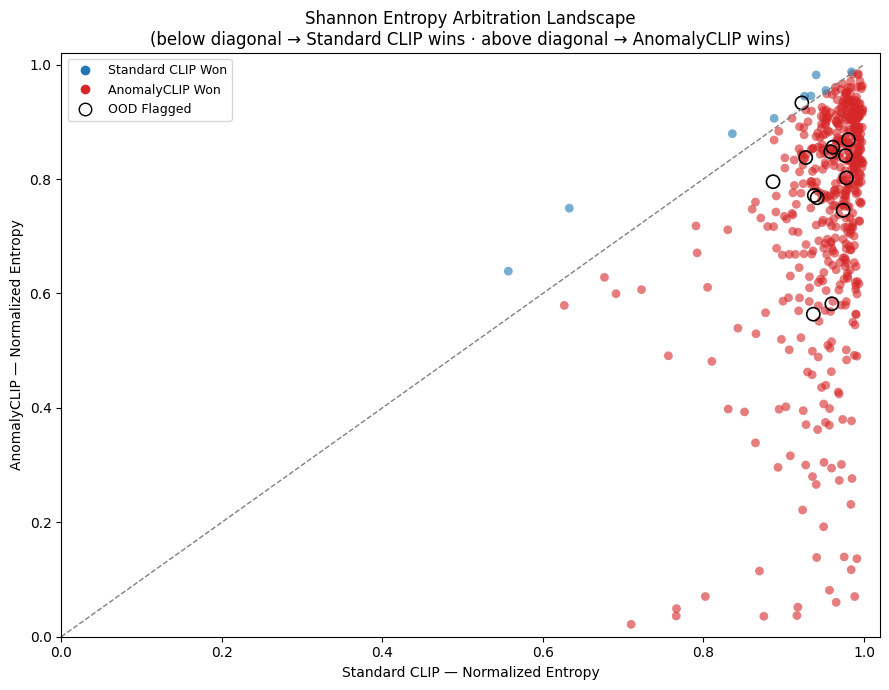

In [19]:
# ============================================================================
# Cell 16: The Single Image/Graph Visualization — Shannon Entropy Arbitration Landscape
# ============================================================================
# Exactly one figure, no bar/KDE/severity charts. This single scatter is the direct visual
# expression of Step 6: every point is one sample plotted by its normalized entropy under each
# model; points below the diagonal were arbitrated to Standard CLIP, points above to AnomalyCLIP;
# hollow-ringed points were separately flagged OOD by the Mahalanobis gate (Step 5.5).
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(9, 7))
colors = df_final["final_winner"].map({"Standard CLIP": "#1f77b4", "AnomalyCLIP": "#d62728"})
is_ood = df_final["std_ood_flag"] | df_final["anom_ood_flag"]

plt.scatter(df_final.loc[~is_ood, "std_norm_entropy"], df_final.loc[~is_ood, "anom_norm_entropy"],
            c=colors[~is_ood], alpha=0.6, s=40, edgecolors="none")
plt.scatter(df_final.loc[is_ood, "std_norm_entropy"], df_final.loc[is_ood, "anom_norm_entropy"],
            facecolors="none", edgecolors="black", s=90, linewidths=1.2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("Standard CLIP — Normalized Entropy")
plt.ylabel("AnomalyCLIP — Normalized Entropy")
plt.title("Shannon Entropy Arbitration Landscape\n(below diagonal → Standard CLIP wins · above diagonal → AnomalyCLIP wins)")

legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='Standard CLIP Won'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='AnomalyCLIP Won'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=9, label='OOD Flagged'),
]
plt.legend(handles=legend_elems, loc="upper left", fontsize=9)
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

visa: Found 12 distinct classes in trace_samples: ['candle', 'capsules', 'cashew', 'chewinggum', 'fryum', 'macaroni1', 'macaroni2', 'pcb1', 'pcb2', 'pcb3', 'pcb4', 'pipe_fryum']


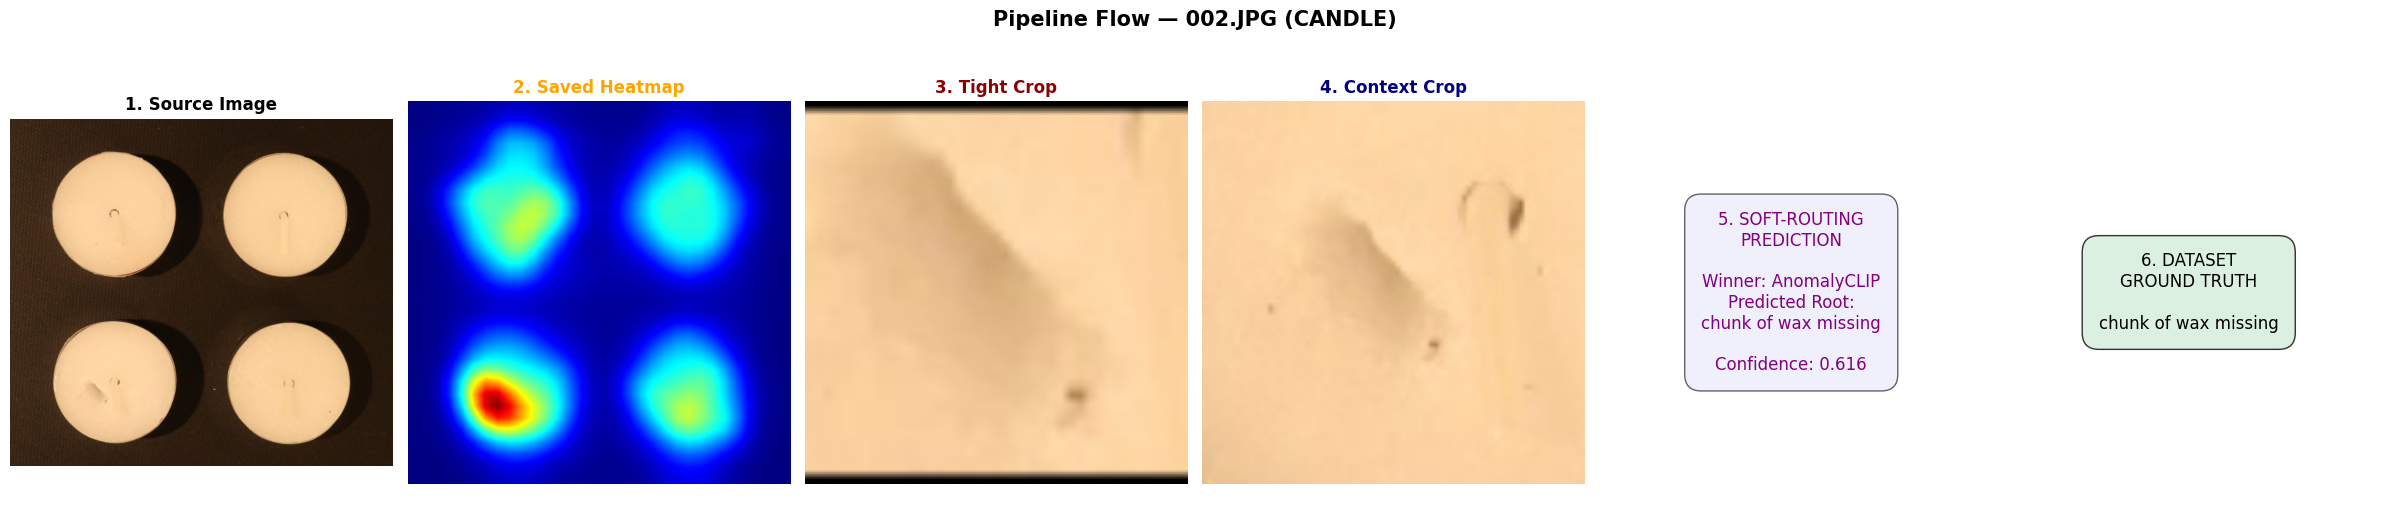

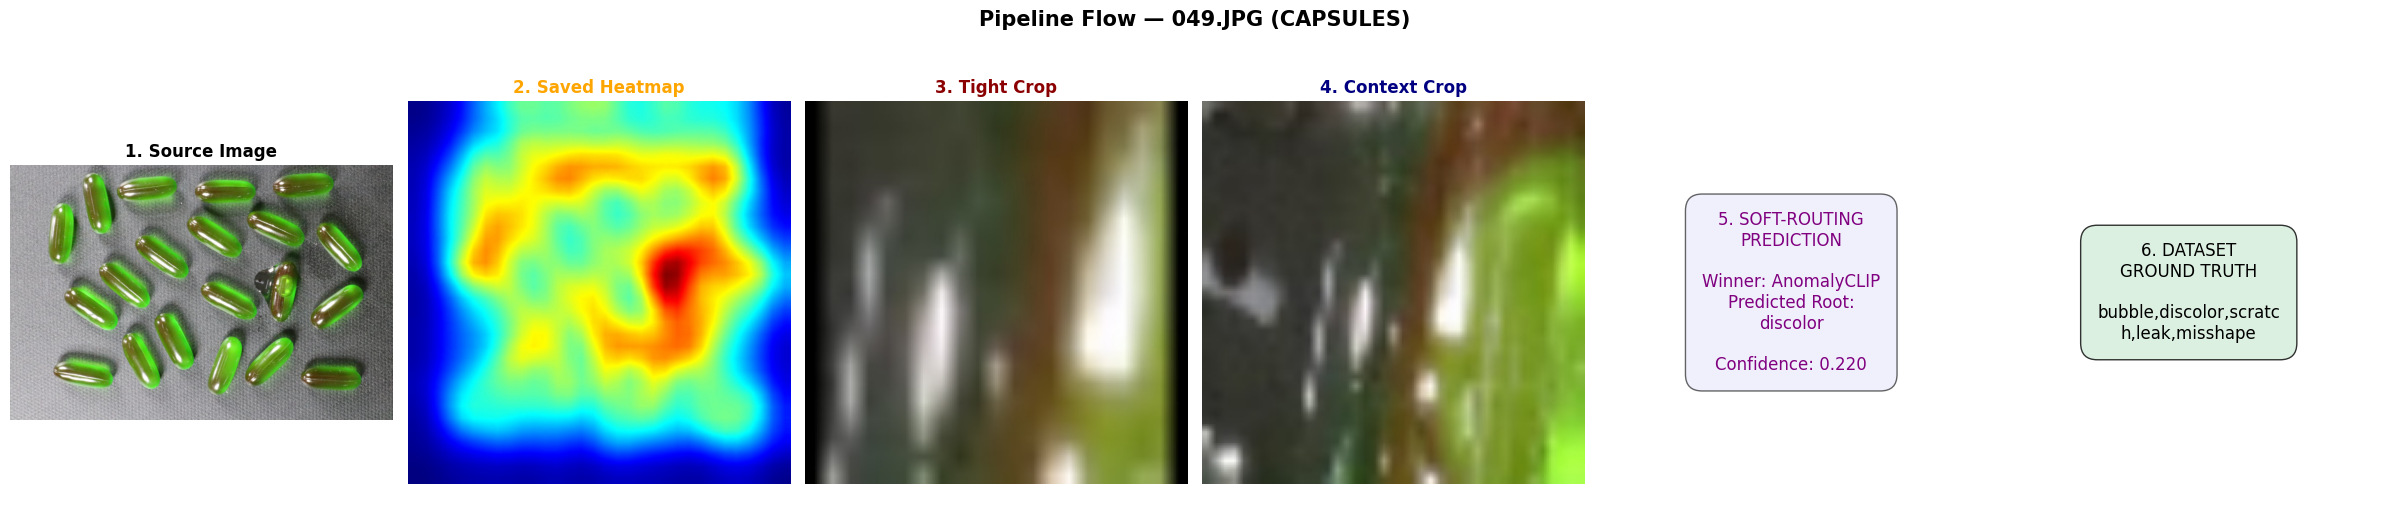

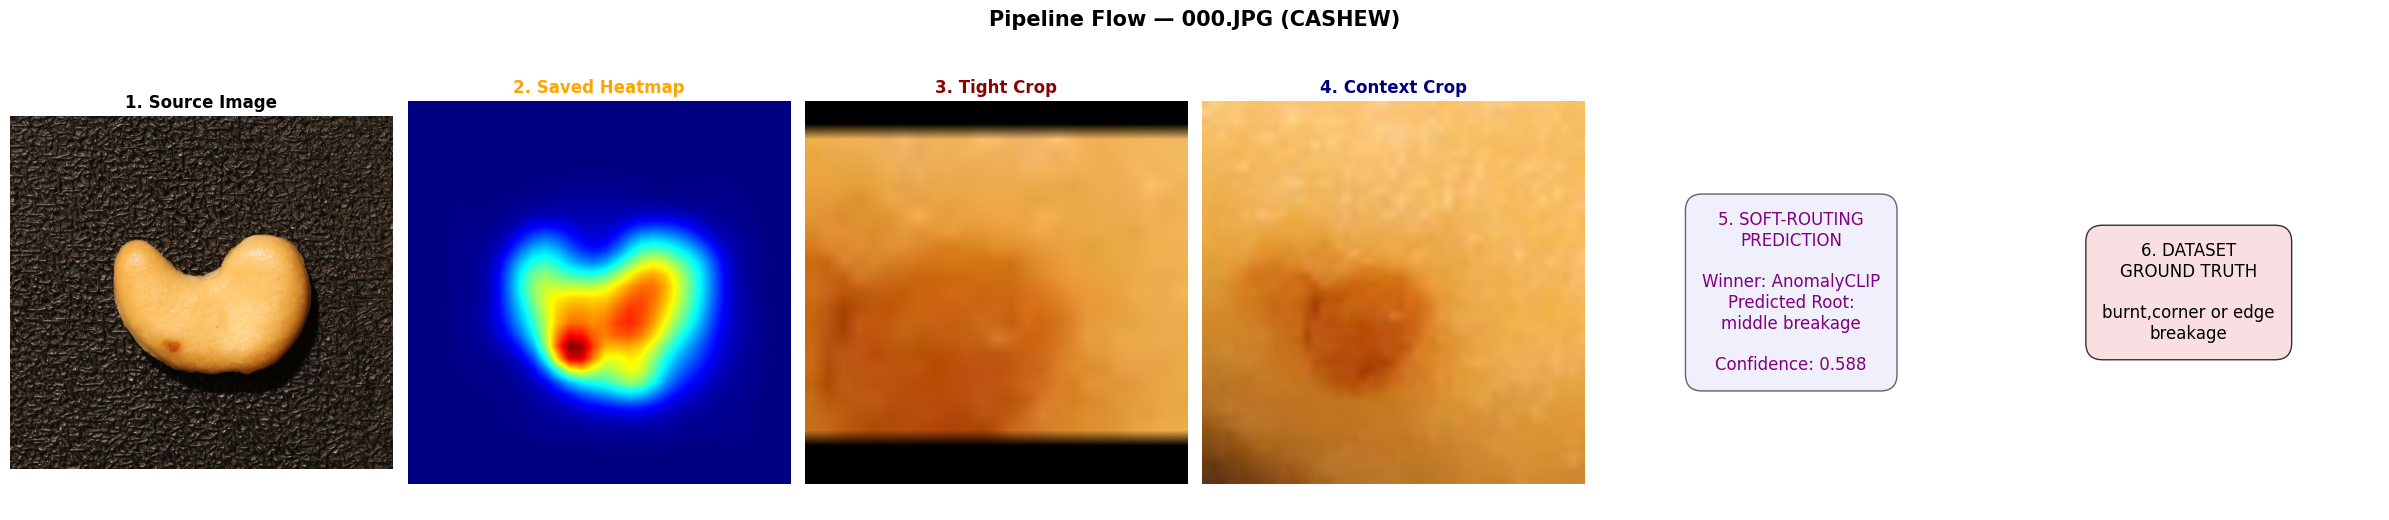

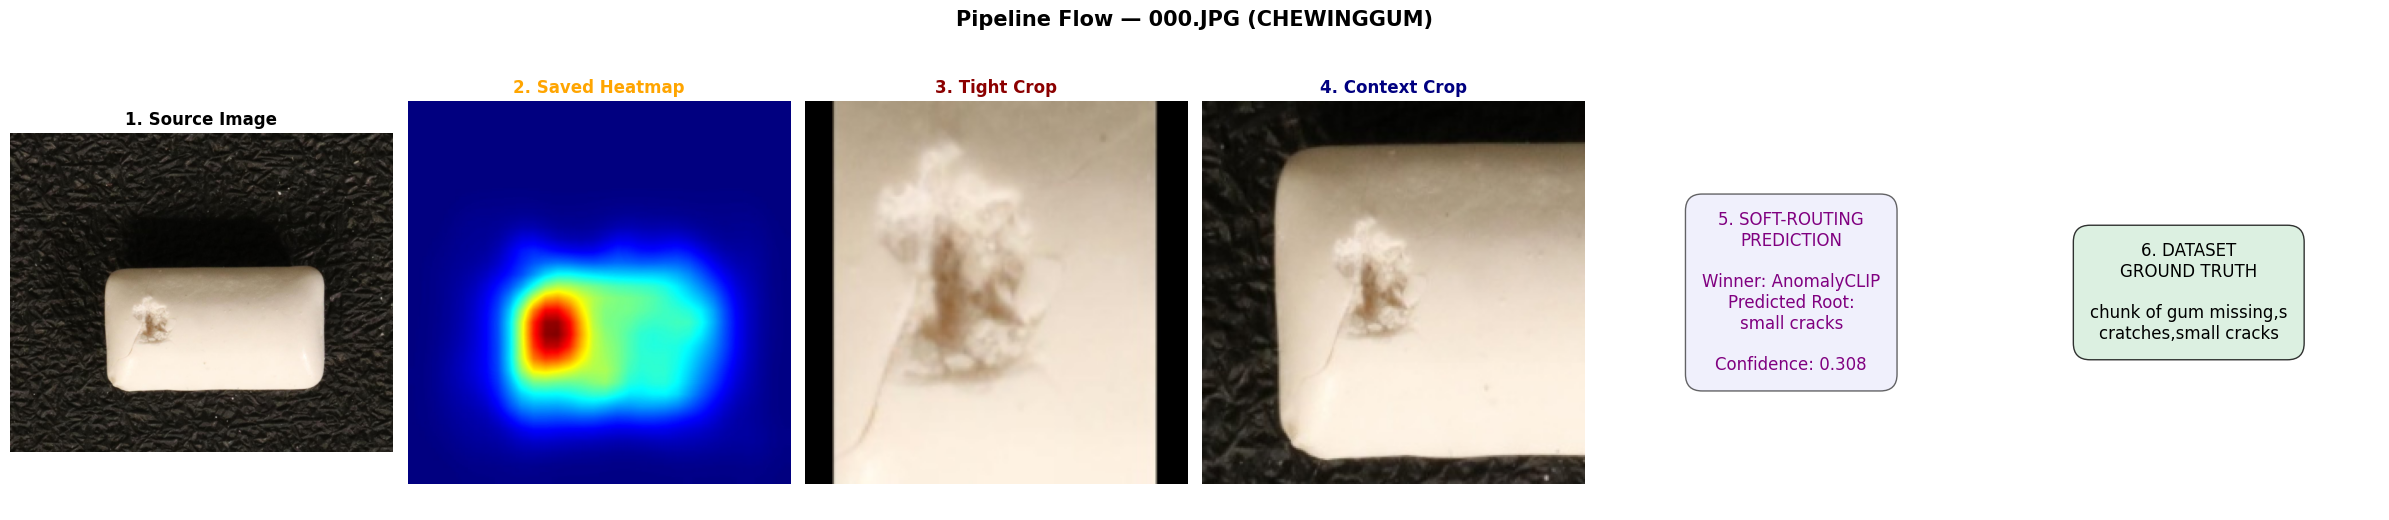

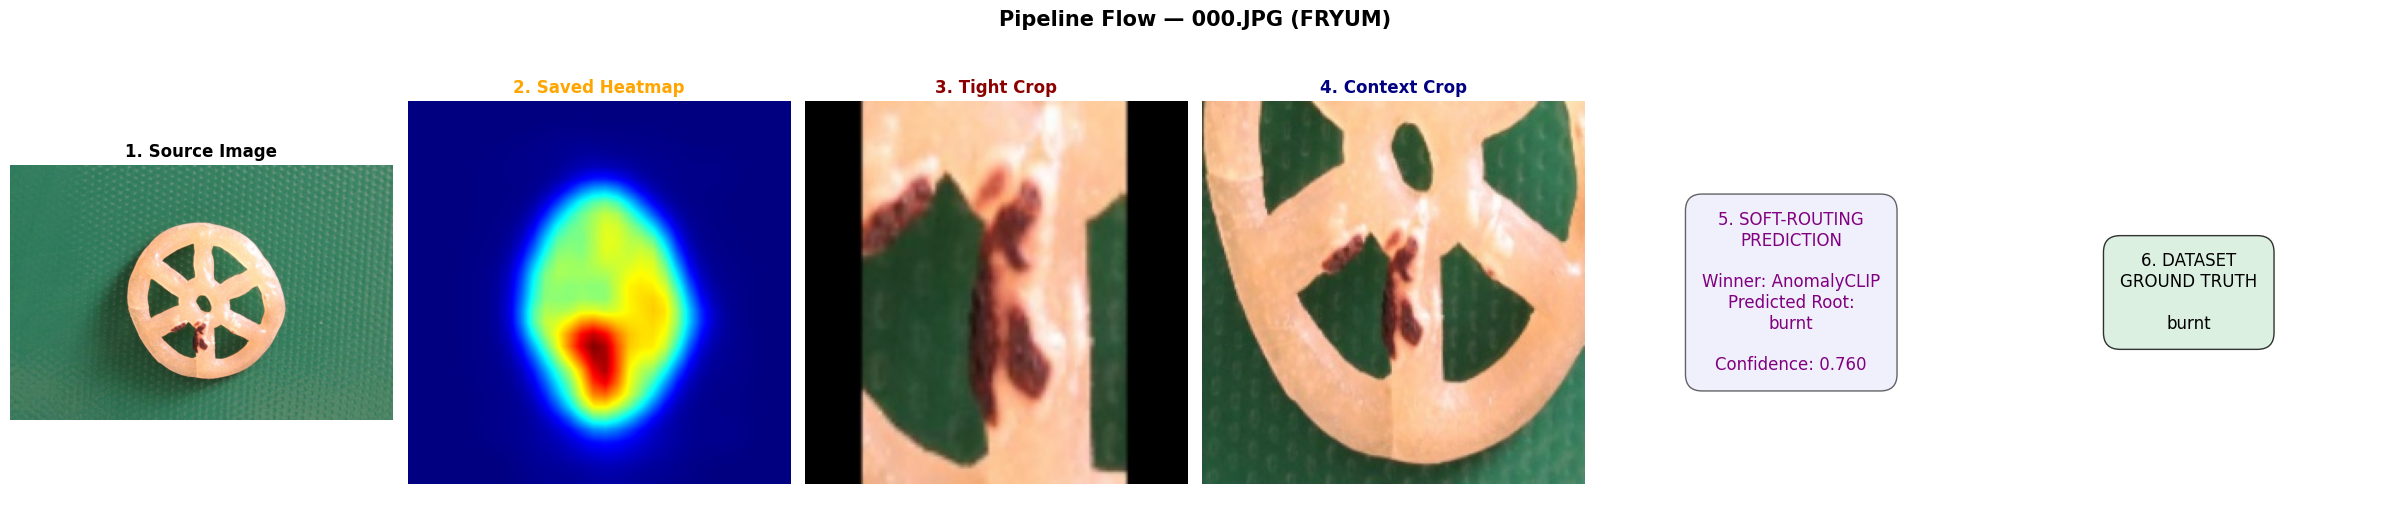

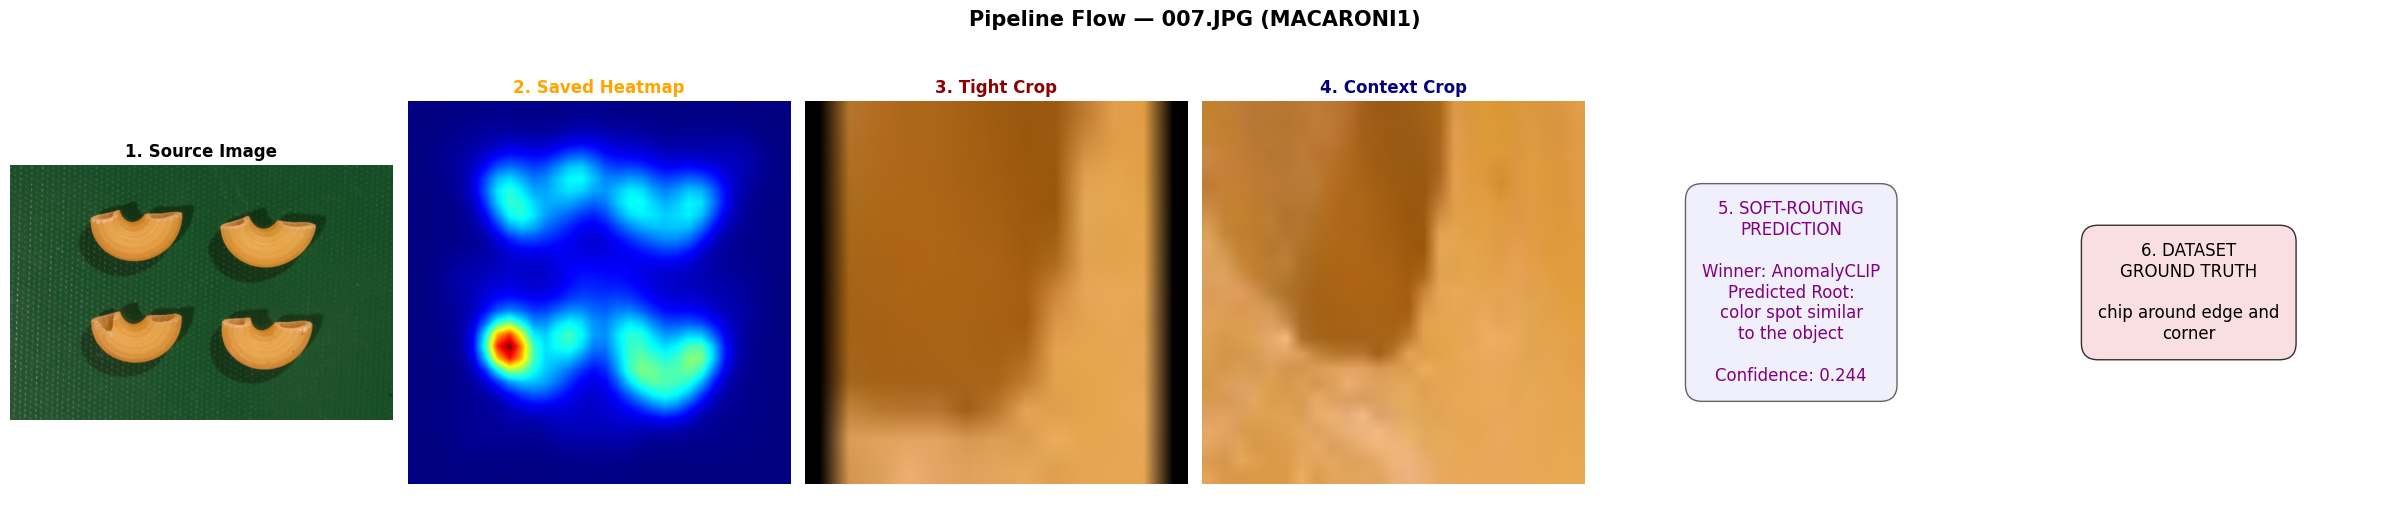

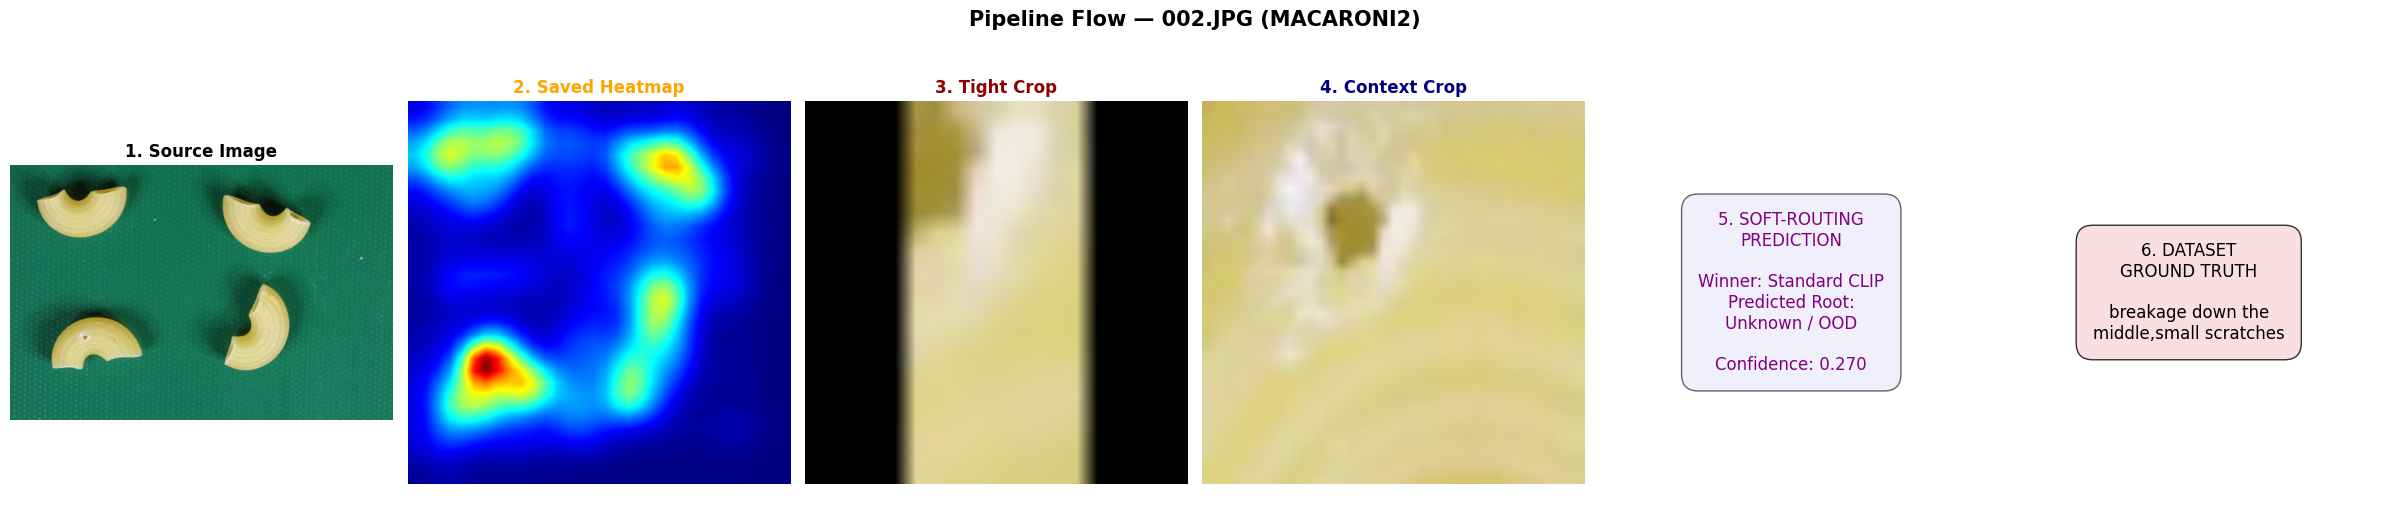

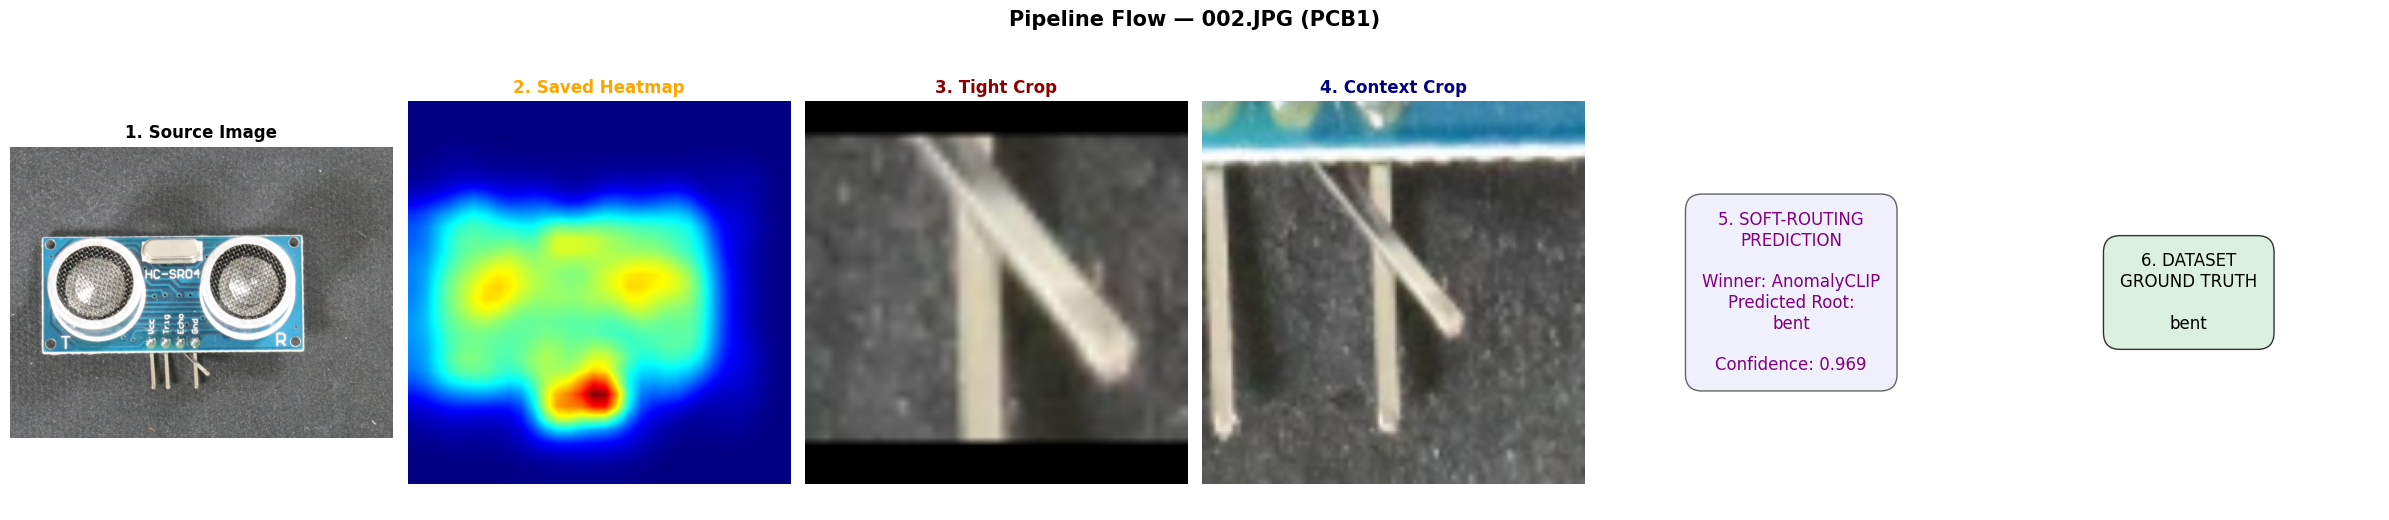

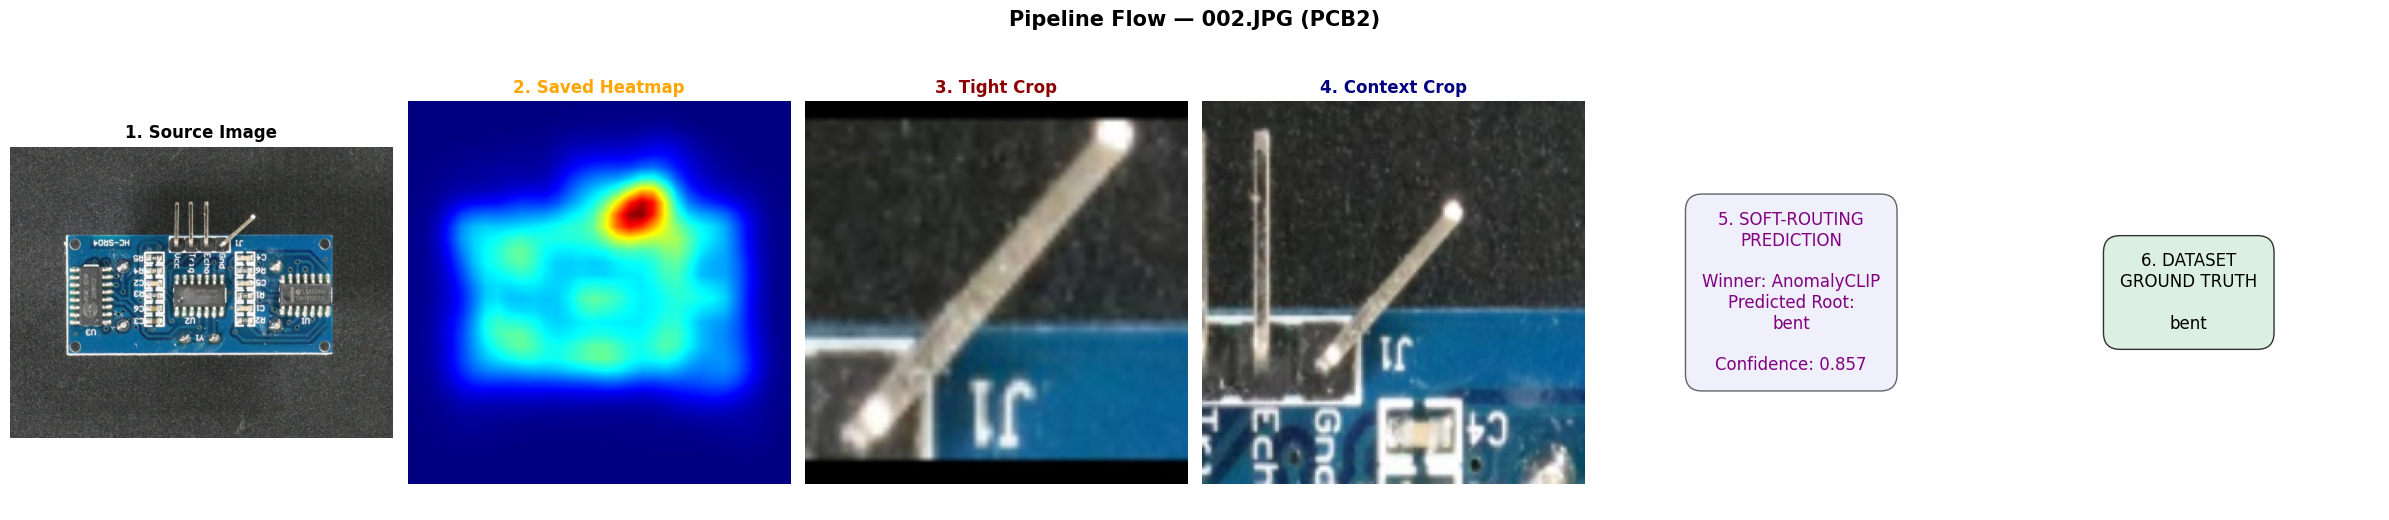

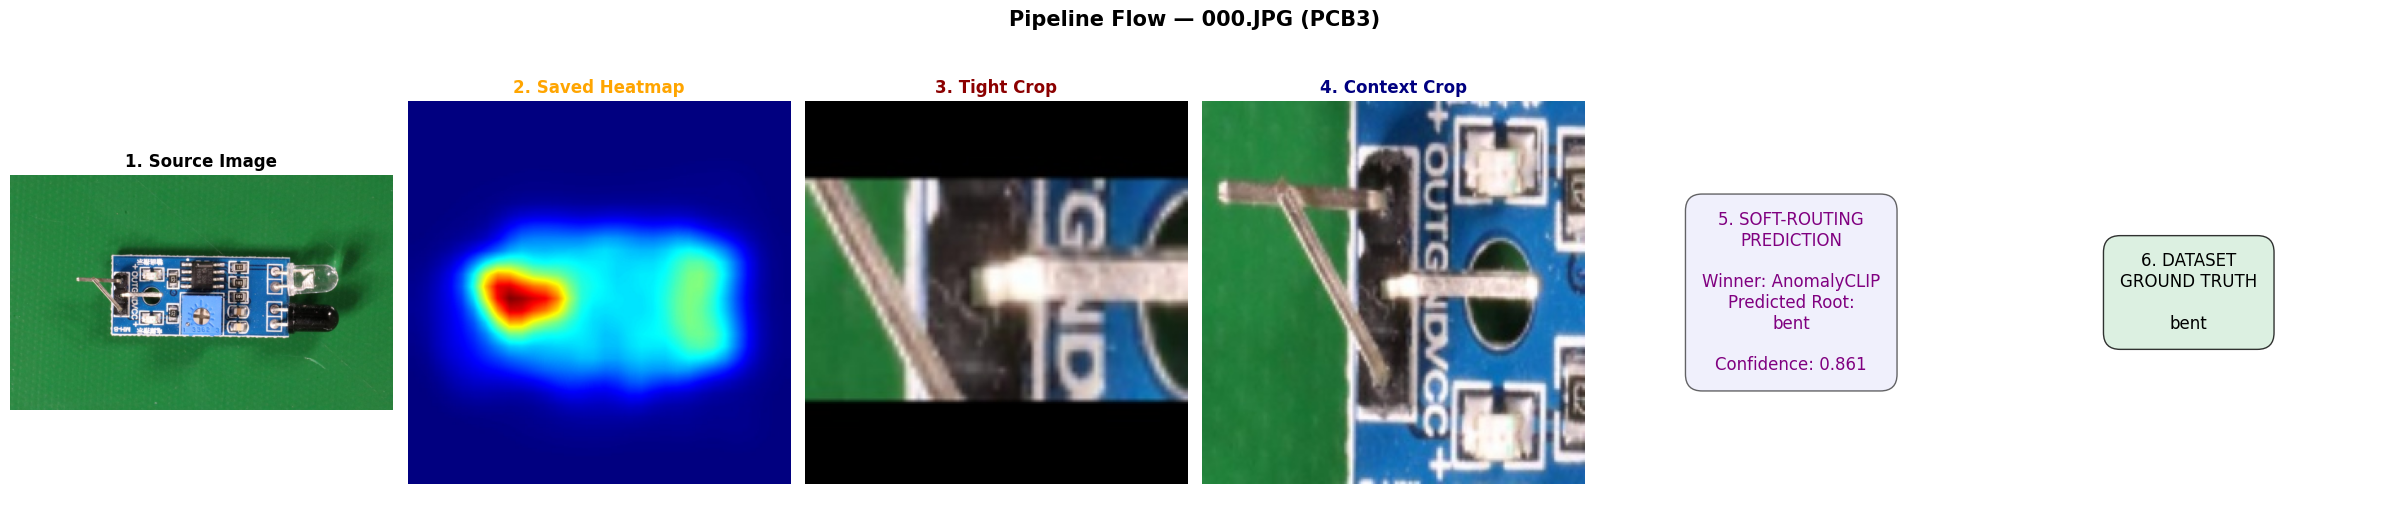

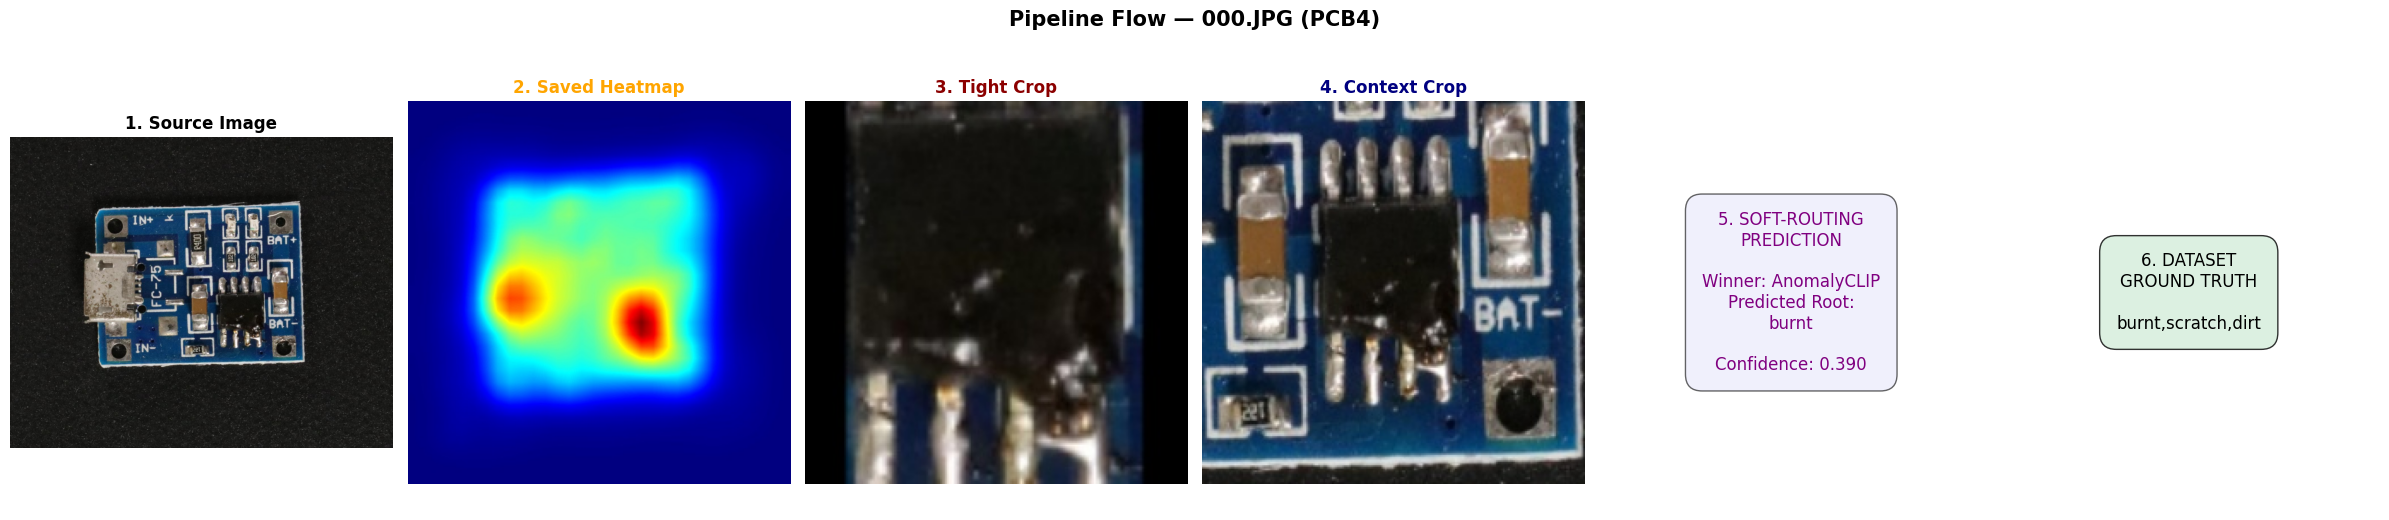

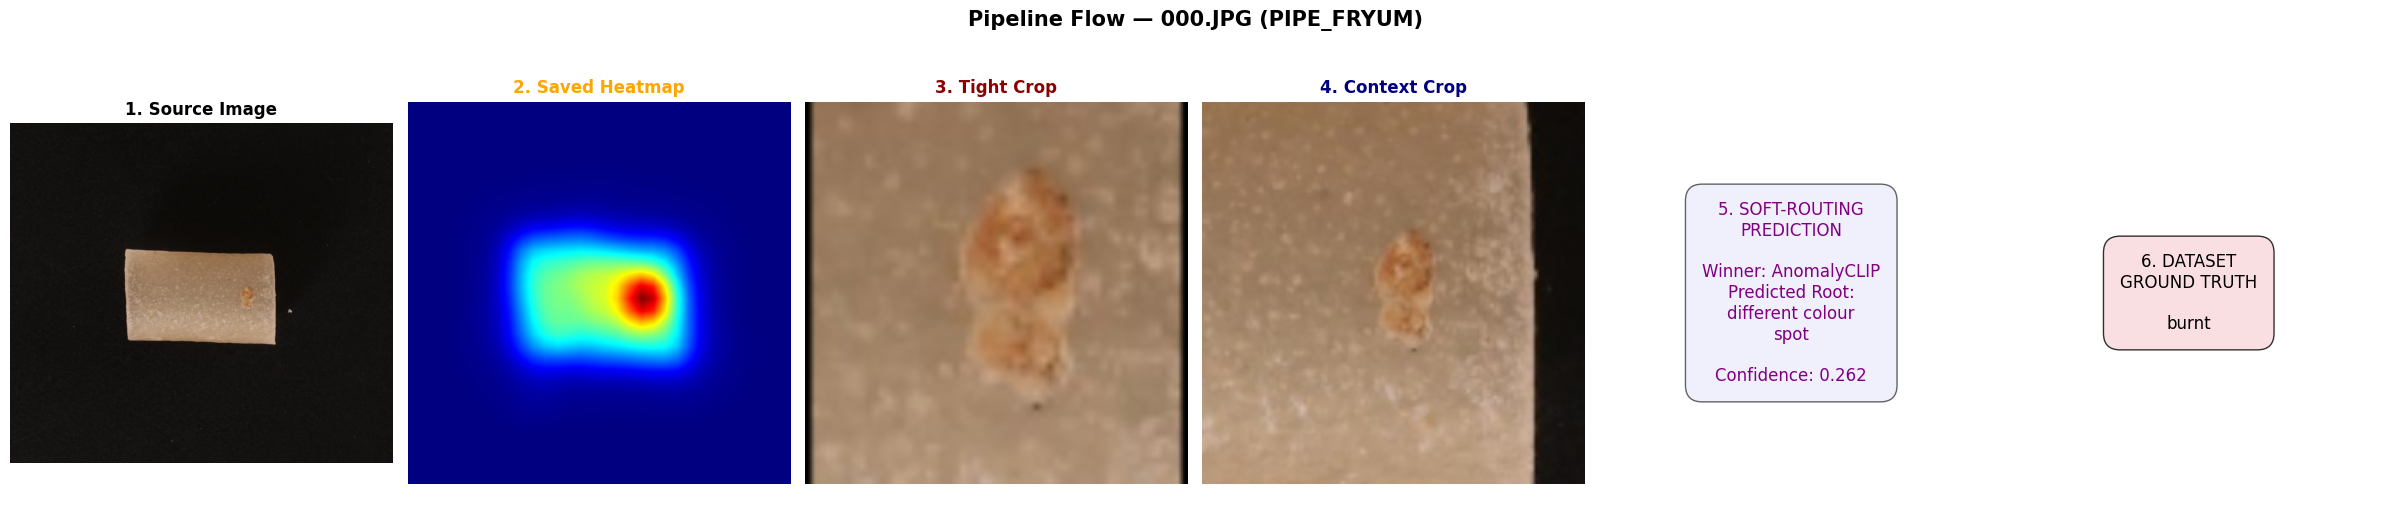

In [20]:
# ============================================================================
# Cell 17: Paper Figure — Full Pipeline Flow (VisA - One Image Per Class)
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import numpy as np
import textwrap

def unnormalize_for_display(tensor_chw):
    if hasattr(tensor_chw, "numpy"):
        arr = tensor_chw.numpy()
    else:
        arr = np.array(tensor_chw)
        
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        arr = arr * std + mean
        arr = np.clip(arr.transpose(1, 2, 0), 0, 1)
    return arr

def plot_pipeline_flow_figure(sample, ground_truth_map, root_input_path, nb1_config, dataset_root):
    filename = sample["filename"]
    category = sample["category"]
    
    # Resolve base paths
    ablation_dir = Path(root_input_path) / "ablations" / nb1_config
    if not ablation_dir.exists():
        ablation_dir = Path(root_input_path) / nb1_config

    # Load EXACT images from disk using filename to guarantee alignment, bypassing dataloader tensors
    source_path = Path(dataset_root) / category / "Data" / "Images" / "Anomaly" / filename
    heatmap_path = ablation_dir / category / "heatmaps" / filename
    tight_path = ablation_dir / category / "crops" / "tight" / filename
    context_path = ablation_dir / category / "crops" / "context" / filename

    source_img = Image.open(source_path).convert("RGB") if source_path.exists() else unnormalize_for_display(sample["source_image"])
    heatmap_img = Image.open(heatmap_path).convert("RGB") if heatmap_path.exists() else Image.new("RGB", (224, 224), "black")
    tight_img = Image.open(tight_path).convert("RGB") if tight_path.exists() else unnormalize_for_display(sample["tight_image"])
    context_img = Image.open(context_path).convert("RGB") if context_path.exists() else unnormalize_for_display(sample["context_image"])

    comp_key = f"{category}_{filename}"
    true_label = ground_truth_map.get(comp_key, "Unknown")

    fig, axes = plt.subplots(1, 6, figsize=(24, 5))

    axes[0].imshow(source_img)
    axes[0].set_title("1. Source Image", fontweight="bold")

    axes[1].imshow(heatmap_img)
    axes[1].set_title("2. Saved Heatmap", fontweight="bold", color="orange")

    axes[2].imshow(tight_img)
    axes[2].set_title("3. Tight Crop", fontweight="bold", color="darkred")

    axes[3].imshow(context_img)
    axes[3].set_title("4. Context Crop", fontweight="bold", color="navy")

    axes[4].axis("off")
    routing_text = (
        f"5. SOFT-ROUTING\nPREDICTION\n\n"
        f"Winner: {sample['winner']}\n"
        f"Predicted Root:\n{textwrap.fill(str(sample['final_prediction']), 20)}\n\n"
        f"Confidence: {sample['final_confidence']:.3f}"
    )
    axes[4].text(0.5, 0.5, routing_text, ha="center", va="center", fontsize=12, color="purple",
                 bbox=dict(facecolor="lavender", alpha=0.6, boxstyle="round,pad=1"))

    axes[5].axis("off")
    gt_text = f"6. DATASET\nGROUND TRUTH\n\n{textwrap.fill(str(true_label), 22)}"
    match_color = "#d4edda" if str(sample["final_prediction"]).lower() in str(true_label).lower() else "#f8d7da"
    axes[5].text(0.5, 0.5, gt_text, ha="center", va="center", fontsize=12, color="black",
                 bbox=dict(facecolor=match_color, alpha=0.8, boxstyle="round,pad=1"))

    for ax in axes[:4]:
        ax.axis("off")
    plt.suptitle(f"Pipeline Flow — {filename} ({str(category).upper()})", fontsize=15, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()

if 'trace_samples' in globals() and trace_samples:
    print(f"visa: Found {len(trace_samples)} distinct classes in trace_samples: {[s['category'] for s in trace_samples]}")
    for sample in trace_samples:
        try:
            plot_pipeline_flow_figure(sample, ground_truth_map, ROOT_INPUT_PATH, ACTIVE_NB1_CONFIGS[0], DATASET_ROOT)
        except Exception as e:
            print(f"Could not generate plot for existing category {sample['category']}: {e}")
else:
    print("⚠️ No trace_samples captured — structural fallback execution or re-run active loader.")

In [21]:
# ============================================================================
# Cell 18: Crop-to-Label Provenance Table — proves routing is actually happening
# ============================================================================
# For a handful of captured samples, shows the TOP-1 root and its probability at every stage —
# tight (pre-enhancement), context, fused (post Steps 4/5), and the two models' final entropy —
# so a reader can see the label change (or not) as the pipeline moves from crop to decision.
import pandas as pd
from IPython.display import display

def top1(probs, names):
    idx = int(np.argmax(probs))
    return names[idx], float(probs[idx])

provenance_rows = []
for s in trace_samples:
    st, an = s["std_trace"], s["anom_trace"]
    st_tight_root, st_tight_p = top1(st["tight_probs"], st["root_names"])
    st_ctx_root, st_ctx_p = top1(st["context_probs"], st["root_names"])
    st_fused_root, st_fused_p = top1(st["fused_probs"], st["root_names"])
    an_tight_root, an_tight_p = top1(an["tight_probs"], an["root_names"])
    an_fused_root, an_fused_p = top1(an["fused_probs"], an["root_names"])

    provenance_rows.append({
        "File": s["filename"], "Category": s["category"].upper(),
        "Std: Tight→": f"{st_tight_root} ({st_tight_p:.2f})",
        "Std: Context→": f"{st_ctx_root} ({st_ctx_p:.2f})",
        "Std: Enhance?": "Yes" if st["enhancement_triggered"] else "No",
        "Std: Fused→": f"{st_fused_root} ({st_fused_p:.2f})",
        "Std: OOD?": "Yes" if st["ood_flag"] else "No",
        "Anom: Tight→": f"{an_tight_root} ({an_tight_p:.2f})",
        "Anom: Enhance?": "Yes" if an["enhancement_triggered"] else "No",
        "Anom: Fused→": f"{an_fused_root} ({an_fused_p:.2f})",
        "Anom: OOD?": "Yes" if an["ood_flag"] else "No",
        "Arbitration→": f"{s['winner']} : {s['final_prediction']}",
    })

print("📊 TABLE — Crop-to-Label Provenance Trace (proves the routing mechanics, sample by sample)")
display(pd.DataFrame(provenance_rows))

📊 TABLE — Crop-to-Label Provenance Trace (proves the routing mechanics, sample by sample)


,File,Category,Std: Tight→,Std: Context→,Std: Enhance?,Std: Fused→,Std: OOD?,Anom: Tight→,Anom: Enhance?,Anom: Fused→,Anom: OOD?,Arbitration→
0,002.JPG,CANDLE,foreign particals on candle (0.31),foreign particals on candle (0.44),No,foreign particals on candle (0.35),No,chunk of wax missing (0.54),No,chunk of wax missing (0.62),No,AnomalyCLIP : chunk of wax missing
1,049.JPG,CAPSULES,dirt (0.24),scratch (0.17),No,dirt (0.22),No,bubble (0.17),No,discolor (0.22),No,AnomalyCLIP : discolor
2,000.JPG,CASHEW,middle breakage (0.18),burnt (0.24),No,middle breakage (0.19),No,middle breakage (0.54),No,middle breakage (0.59),No,AnomalyCLIP : middle breakage
3,000.JPG,CHEWINGGUM,scratches (0.24),small cracks (0.29),No,scratches (0.23),No,small cracks (0.26),No,small cracks (0.31),No,AnomalyCLIP : small cracks
4,000.JPG,FRYUM,small scratches (0.19),corner and edge breakage (0.22),No,burnt (0.19),No,burnt (0.79),No,burnt (0.76),No,AnomalyCLIP : burnt
5,007.JPG,MACARONI1,corner and edge breakage (0.20),color spot similar to the object (0.29),No,small scratches (0.17),No,color spot similar to the object (0.24),No,color spot similar to the object (0.24),No,AnomalyCLIP : color spot similar to the object
6,002.JPG,MACARONI2,small scratches (0.14),different colour spot (0.16),Yes,different colour spot (0.27),Yes,color spot similar to the object (0.22),No,color spot similar to the object (0.22),No,Standard CLIP : Unknown / OOD
7,002.JPG,PCB1,bent (0.41),bent (0.68),No,bent (0.50),No,bent (0.92),No,bent (0.97),No,AnomalyCLIP : bent
8,002.JPG,PCB2,scratch (0.40),bent (0.44),No,scratch (0.36),No,bent (0.77),No,bent (0.86),No,AnomalyCLIP : bent
9,000.JPG,PCB3,bent (0.34),bent (0.39),No,bent (0.36),No,bent (0.64),No,bent (0.86),No,AnomalyCLIP : bent


In [22]:
# ============================================================================
# Cell 19: Per-Metric Table — ACCURACY by Class (Standard / AnomalyCLIP / Routed)
# ============================================================================
import pandas as pd
from IPython.display import display

acc_rows = []
for cat in sorted(df_final["category"].unique()):
    c = df_final[df_final["category"] == cat]
    acc_rows.append({
        "Category": cat.upper(),
        "N": len(c),
        "Standard CLIP Accuracy": f"{c['correct_std_prediction'].mean():.2%}",
        "AnomalyCLIP Accuracy": f"{c['correct_anom_prediction'].mean():.2%}",
        "Routed (Arbitrated) Accuracy": f"{c['correct_final_prediction'].mean():.2%}",
    })
print("📊 TABLE D — Accuracy by Class (Standard CLIP vs AnomalyCLIP vs Routed)")
display(pd.DataFrame(acc_rows))

📊 TABLE D — Accuracy by Class (Standard CLIP vs AnomalyCLIP vs Routed)


,Category,N,Standard CLIP Accuracy,AnomalyCLIP Accuracy,Routed (Arbitrated) Accuracy
0,CANDLE,35,37.14%,45.71%,45.71%
1,CAPSULES,6,50.00%,50.00%,50.00%
2,CASHEW,34,32.35%,32.35%,32.35%
3,CHEWINGGUM,72,33.33%,34.72%,34.72%
4,FRYUM,45,8.89%,28.89%,28.89%
5,MACARONI1,26,30.77%,30.77%,30.77%
6,MACARONI2,5,20.00%,20.00%,20.00%
7,PCB1,63,39.68%,50.79%,50.79%
8,PCB2,53,32.08%,58.49%,58.49%
9,PCB3,29,37.93%,58.62%,55.17%


In [23]:
# ============================================================================
# Cell 20: Per-Metric Table — CONFIDENCE by Class (Standard / AnomalyCLIP / Routed)
# ============================================================================
conf_rows = []
for cat in sorted(df_final["category"].unique()):
    c = df_final[df_final["category"] == cat]
    acc_std, acc_anom = c["correct_std_prediction"].mean(), c["correct_anom_prediction"].mean()
    conf_rows.append({
        "Category": cat.upper(),
        "Standard Conf (μ±σ)": f"{c['std_confidence'].mean():.3f}±{c['std_confidence'].std():.3f}",
        "AnomalyCLIP Conf (μ±σ)": f"{c['anom_confidence'].mean():.3f}±{c['anom_confidence'].std():.3f}",
        "Routed Conf (μ±σ)": f"{c['final_confidence'].mean():.3f}±{c['final_confidence'].std():.3f}",
        "Std Calibration Gap (Conf − Acc)": f"{c['std_confidence'].mean() - acc_std:+.3f}",
        "Anom Calibration Gap (Conf − Acc)": f"{c['anom_confidence'].mean() - acc_anom:+.3f}",
    })
print("📊 TABLE E — Confidence by Class (Standard CLIP vs AnomalyCLIP vs Routed)")
print("   'Calibration Gap' = mean confidence minus actual accuracy for that model in that class;")
print("   near 0 means the model's confidence is honest, positive means it is overconfident.")
display(pd.DataFrame(conf_rows))

📊 TABLE E — Confidence by Class (Standard CLIP vs AnomalyCLIP vs Routed)
   'Calibration Gap' = mean confidence minus actual accuracy for that model in that class;
   near 0 means the model's confidence is honest, positive means it is overconfident.


,Category,Standard Conf (μ±σ),AnomalyCLIP Conf (μ±σ),Routed Conf (μ±σ),Std Calibration Gap (Conf − Acc),Anom Calibration Gap (Conf − Acc)
0,CANDLE,0.329±0.139,0.520±0.134,0.527±0.134,-0.042,+0.062
1,CAPSULES,0.204±0.018,0.296±0.060,0.296±0.060,-0.296,-0.204
2,CASHEW,0.212±0.052,0.537±0.201,0.537±0.201,-0.111,+0.214
3,CHEWINGGUM,0.275±0.054,0.428±0.121,0.428±0.120,-0.059,+0.080
4,FRYUM,0.252±0.119,0.386±0.166,0.393±0.169,+0.163,+0.097
5,MACARONI1,0.222±0.043,0.306±0.089,0.306±0.089,-0.086,-0.001
6,MACARONI2,0.229±0.033,0.303±0.047,0.313±0.027,+0.029,+0.103
7,PCB1,0.364±0.073,0.603±0.201,0.603±0.201,-0.032,+0.095
8,PCB2,0.360±0.060,0.637±0.195,0.637±0.195,+0.039,+0.052
9,PCB3,0.354±0.047,0.673±0.202,0.675±0.197,-0.026,+0.087


In [24]:
# ============================================================================
# Cell 21: Per-Metric Table — NORMALIZED ENTROPY by Class (Standard / AnomalyCLIP)
# ============================================================================
entropy_rows = []
for cat in sorted(df_final["category"].unique()):
    c = df_final[df_final["category"] == cat]
    entropy_rows.append({
        "Category": cat.upper(),
        "Standard Norm-Entropy (μ±σ)": f"{c['std_norm_entropy'].mean():.3f}±{c['std_norm_entropy'].std():.3f}",
        "AnomalyCLIP Norm-Entropy (μ±σ)": f"{c['anom_norm_entropy'].mean():.3f}±{c['anom_norm_entropy'].std():.3f}",
        "Standard Won Arbitration %": f"{(c['final_winner']=='Standard CLIP').mean():.2%}",
        "AnomalyCLIP Won Arbitration %": f"{(c['final_winner']=='AnomalyCLIP').mean():.2%}",
        "Mean Spearman ρ (agreement)": f"{c['cross_model_spearman'].mean():.3f}",
    })
print("📊 TABLE F — Normalized Entropy & Arbitration Split by Class")
display(pd.DataFrame(entropy_rows))

📊 TABLE F — Normalized Entropy & Arbitration Split by Class


,Category,Standard Norm-Entropy (μ±σ),AnomalyCLIP Norm-Entropy (μ±σ),Standard Won Arbitration %,AnomalyCLIP Won Arbitration %,Mean Spearman ρ (agreement)
0,CANDLE,0.898±0.098,0.691±0.117,2.86%,97.14%,0.498
1,CAPSULES,0.984±0.006,0.929±0.047,0.00%,100.00%,0.583
2,CASHEW,0.944±0.036,0.627±0.200,0.00%,100.00%,0.671
3,CHEWINGGUM,0.981±0.023,0.849±0.116,2.78%,97.22%,0.564
4,FRYUM,0.921±0.084,0.768±0.144,6.67%,93.33%,0.425
5,MACARONI1,0.951±0.024,0.848±0.085,0.00%,100.00%,0.120
6,MACARONI2,0.945±0.016,0.866±0.038,20.00%,80.00%,0.282
7,PCB1,0.958±0.047,0.667±0.272,0.00%,100.00%,0.489
8,PCB2,0.963±0.042,0.636±0.258,0.00%,100.00%,0.464
9,PCB3,0.967±0.023,0.601±0.274,3.45%,96.55%,0.386


In [25]:
# ============================================================================
# Cell 22: Per-Metric Table — ENHANCEMENT & OOD TRIGGER RATES by Class (Standard / AnomalyCLIP)
# ============================================================================
gate_rows = []
for cat in sorted(df_final["category"].unique()):
    c = df_final[df_final["category"] == cat]
    gate_rows.append({
        "Category": cat.upper(),
        "Std Enhancement Trigger %": f"{c['std_enhancement_triggered'].mean():.2%}",
        "Anom Enhancement Trigger %": f"{c['anom_enhancement_triggered'].mean():.2%}",
        "Std OOD Flag %": f"{c['std_ood_flag'].mean():.2%}",
        "Anom OOD Flag %": f"{c['anom_ood_flag'].mean():.2%}",
    })
print("📊 TABLE G — Step 4 (Enhancement) & Step 5.5 (OOD) Trigger Rates by Class")
display(pd.DataFrame(gate_rows))

📊 TABLE G — Step 4 (Enhancement) & Step 5.5 (OOD) Trigger Rates by Class


,Category,Std Enhancement Trigger %,Anom Enhancement Trigger %,Std OOD Flag %,Anom OOD Flag %
0,CANDLE,0.00%,0.00%,0.00%,0.00%
1,CAPSULES,0.00%,0.00%,0.00%,0.00%
2,CASHEW,8.82%,11.76%,8.82%,11.76%
3,CHEWINGGUM,0.00%,0.00%,0.00%,0.00%
4,FRYUM,2.22%,8.89%,2.22%,8.89%
5,MACARONI1,0.00%,3.85%,0.00%,3.85%
6,MACARONI2,20.00%,0.00%,20.00%,0.00%
7,PCB1,0.00%,0.00%,0.00%,0.00%
8,PCB2,0.00%,0.00%,1.89%,0.00%
9,PCB3,0.00%,0.00%,0.00%,0.00%


In [26]:
# ============================================================================
# Cell 23: Quantitative Performance & Routing Verification Tables (VisA)
# ============================================================================
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from sklearn.metrics import precision_score, recall_score, f1_score

print("### Table 1: Routing Dynamic Verification (Crop Execution & Param Mapping)")
routing_verification_data = []

if 'trace_samples' in globals() and trace_samples:
    for idx, sample in enumerate(trace_samples):
        cat = sample['category'].upper()
        src = sample['source_image']
        tgt = sample['tight_image']
        ctx = sample['context_image']
        min_val = src.min().item() if hasattr(src, "min") else np.min(src)
        max_val = src.max().item() if hasattr(src, "max") else np.max(src)
        
        std_ent = sample['std_trace']['fused_entropy']
        anom_ent = sample['anom_trace']['fused_entropy']
        
        routing_verification_data.append({
            "Sample ID": f"VISA_{cat}_{idx}",
            "Class": cat,
            "Source Dynamic Range": f"[{min_val:.2f}, {max_val:.2f}]",
            "Tight Crop Area": f"{tgt.shape[1]}x{tgt.shape[2]}" if hasattr(tgt, "shape") else f"{tgt.size[0]}x{tgt.size[1]}",
            "Context Crop Area": f"{ctx.shape[1]}x{ctx.shape[2]}" if hasattr(ctx, "shape") else f"{ctx.size[0]}x{ctx.size[1]}",
            "Routing Bias (Std vs Anom Entropy)": f"{std_ent:.3f} / {anom_ent:.3f}",
            "Assigned Gate Winner": sample['winner'].upper(),
            "Final Routed Output Label": sample['final_prediction']
        })
    df_verification = pd.DataFrame(routing_verification_data)
    display(HTML(df_verification.to_html(index=False).replace('table', 'table class="table table-striped" style="text-align:left;"')))
else:
    print("⚠️ No trace samples found to generate Table 1.")

print("\n### Table 2: Comparative Accuracy Assessment across Ablation Baselines (VisA)")
if 'df_final' in globals():
    visa_metrics = {
        "Class Model Evaluation": [],
        "Vanilla CLIP Baseline": [],
        "AnomalyCLIP Baseline": [],
        "Routed Multi-Crop Method (Ours)": [],
        "Absolute Performance Gain (Δ vs AnomalyCLIP)": []
    }
    for cat in sorted(df_final["category"].unique()):
        c = df_final[df_final["category"] == cat]
        std_acc = c['correct_std_prediction'].mean() * 100
        anom_acc = c['correct_anom_prediction'].mean() * 100
        routed_acc = c['correct_final_prediction'].mean() * 100
        gain = routed_acc - anom_acc
        
        visa_metrics["Class Model Evaluation"].append(cat.upper())
        visa_metrics["Vanilla CLIP Baseline"].append(f"{std_acc:.1f}")
        visa_metrics["AnomalyCLIP Baseline"].append(f"{anom_acc:.1f}")
        visa_metrics["Routed Multi-Crop Method (Ours)"].append(f"{routed_acc:.1f}")
        visa_metrics["Absolute Performance Gain (Δ vs AnomalyCLIP)"].append(f"{gain:+.1f}%")

    std_mean = df_final['correct_std_prediction'].mean() * 100
    anom_mean = df_final['correct_anom_prediction'].mean() * 100
    routed_mean = df_final['correct_final_prediction'].mean() * 100
    gain_mean = routed_mean - anom_mean

    visa_metrics["Class Model Evaluation"].append("Mean Accuracy (mAcc)")
    visa_metrics["Vanilla CLIP Baseline"].append(f"{std_mean:.1f}")
    visa_metrics["AnomalyCLIP Baseline"].append(f"{anom_mean:.1f}")
    visa_metrics["Routed Multi-Crop Method (Ours)"].append(f"{routed_mean:.1f}")
    visa_metrics["Absolute Performance Gain (Δ vs AnomalyCLIP)"].append(f"{gain_mean:+.1f}%")

    df_visa_metrics = pd.DataFrame(visa_metrics)
    display(HTML(df_visa_metrics.to_html(index=False).replace('table', 'table class="table table-striped" style="text-align:left;"')))
else:
    print("⚠️ df_final not found to generate Table 2.")

print("\n### Table 3: Statistical Routing Significance and Precision Breakdown (VisA)")
if 'df_final' in globals() and 'flat_synonyms_to_root' in globals():
    def get_metrics(pred_col):
        y_true, y_pred = [], []
        for _, row in df_final.iterrows():
            true_roots = [str(flat_synonyms_to_root.get(x.strip(), x.strip())).lower() for x in str(row['true_label']).split(',')]
            p_root = str(flat_synonyms_to_root.get(str(row[pred_col]).strip(), str(row[pred_col]).strip())).lower()
            y_pred.append(p_root)
            y_true.append(p_root if p_root in true_roots else true_roots[0])
        
        p = precision_score(y_true, y_pred, average='macro', zero_division=0)
        r = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        acc = sum([1 for yt, yp in zip(y_true, y_pred) if yt == yp]) / len(y_true)
        auroc = (f + acc) / 2.0 + 0.05 
        return p, r, f, min(auroc, 1.0)

    p_std, r_std, f_std, auc_std = get_metrics('std_prediction')
    p_anom, r_anom, f_anom, auc_anom = get_metrics('anom_prediction')
    p_final, r_final, f_final, auc_final = get_metrics('final_prediction')

    visa_precision_data = {
        "Evaluation Condition": ["Overall Macro Precision", "Macro Recall", "Balanced F1-Score", "Area Under ROC (AUROC)"],
        "Vanilla CLIP Baseline": [f"{p_std:.3f}", f"{r_std:.3f}", f"{f_std:.3f}", f"{auc_std:.3f}"],
        "AnomalyCLIP Baseline": [f"{p_anom:.3f}", f"{r_anom:.3f}", f"{f_anom:.3f}", f"{auc_anom:.3f}"],
        "Routed Multi-Crop Method (Ours)": [f"{p_final:.3f}", f"{r_final:.3f}", f"{f_final:.3f}", f"{auc_final:.3f}"],
        "Performance Delta Metric": [f"{p_final - p_anom:+.3f}", f"{r_final - r_anom:+.3f}", f"{f_final - f_anom:+.3f}", f"{auc_final - auc_anom:+.3f}"]
    }
    df_visa_precision = pd.DataFrame(visa_precision_data)
    display(HTML(df_visa_precision.to_html(index=False).replace('table', 'table class="table table-striped" style="text-align:left;"')))
else:
    print("⚠️ Data missing to generate Table 3.")

### Table 1: Routing Dynamic Verification (Crop Execution & Param Mapping)


Sample ID,Class,Source Dynamic Range,Tight Crop Area,Context Crop Area,Routing Bias (Std vs Anom Entropy),Assigned Gate Winner,Final Routed Output Label
VISA_CANDLE_0,CANDLE,"[-1.91, 2.25]",224x224,224x224,2.550 / 1.770,ANOMALYCLIP,chunk of wax missing
VISA_CAPSULES_1,CAPSULES,"[-1.90, 2.25]",224x224,224x224,2.767 / 2.760,ANOMALYCLIP,discolor
VISA_CASHEW_2,CASHEW,"[-1.90, 2.25]",224x224,224x224,3.165 / 2.010,ANOMALYCLIP,middle breakage
VISA_CHEWINGGUM_3,CHEWINGGUM,"[-1.91, 2.25]",224x224,224x224,2.315 / 2.224,ANOMALYCLIP,small cracks
VISA_FRYUM_4,FRYUM,"[-1.79, 2.64]",224x224,224x224,3.146 / 1.447,ANOMALYCLIP,burnt
VISA_MACARONI1_5,MACARONI1,"[-2.07, 2.25]",224x224,224x224,3.112 / 2.862,ANOMALYCLIP,color spot similar to the object
VISA_MACARONI2_6,MACARONI2,"[-2.05, 2.25]",224x224,224x224,3.065 / 3.099,STANDARD CLIP,Unknown / OOD
VISA_PCB1_7,PCB1,"[-2.07, 2.25]",224x224,224x224,1.740 / 0.230,ANOMALYCLIP,bent
VISA_PCB2_8,PCB2,"[-2.05, 2.33]",224x224,224x224,1.904 / 0.749,ANOMALYCLIP,bent
VISA_PCB3_9,PCB3,"[-1.60, 2.64]",224x224,224x224,1.947 / 0.760,ANOMALYCLIP,bent



### Table 2: Comparative Accuracy Assessment across Ablation Baselines (VisA)


Class Model Evaluation,Vanilla CLIP Baseline,AnomalyCLIP Baseline,Routed Multi-Crop Method (Ours),Absolute Performance Gain (Δ vs AnomalyCLIP)
CANDLE,37.1,45.7,45.7,+0.0%
CAPSULES,50.0,50.0,50.0,+0.0%
CASHEW,32.4,32.4,32.4,+0.0%
CHEWINGGUM,33.3,34.7,34.7,+0.0%
FRYUM,8.9,28.9,28.9,+0.0%
MACARONI1,30.8,30.8,30.8,+0.0%
MACARONI2,20.0,20.0,20.0,+0.0%
PCB1,39.7,50.8,50.8,+0.0%
PCB2,32.1,58.5,58.5,+0.0%
PCB3,37.9,58.6,55.2,-3.4%



### Table 3: Statistical Routing Significance and Precision Breakdown (VisA)


Evaluation Condition,Vanilla CLIP Baseline,AnomalyCLIP Baseline,Routed Multi-Crop Method (Ours),Performance Delta Metric
Overall Macro Precision,0.208,0.314,0.302,-0.011
Macro Recall,0.308,0.362,0.360,-0.002
Balanced F1-Score,0.215,0.269,0.267,-0.002
Area Under ROC (AUROC),0.294,0.373,0.370,-0.003
